# Partículas elementales: laboratorios 2025/2026
## Práctica 1: física de neutrinos


_Clara Álvarez Luna, Dpto. Física Teórica, <c.a.luna@ucm.es>_

_Patricia Andrea Gutiérrez García, Dpto. Física Teórica, <patricgu@ucm.es>_

_Javier Martínez Martín, Dpto. Física Teórica, <javmar21@ucm.es>_

Nombre: Germán Cousillas Martínez

Grupo laboratorio: L4

Grupo teoría: A

<span style="color:red">**NOTA:**</span> si se existe alguna respuesta a las 3 preguntas abiertas que planteo al final de este informe, pido encarecidamente al / la lector(a) que me escriba a germacou@ucm.es para dirigirme a algún documento que pueda consultar, o que comparta conmigo las suyas propias. Me interesa particularmente la Pregunta 1. Se lo agradezco mucho de antemano

- Germán C.

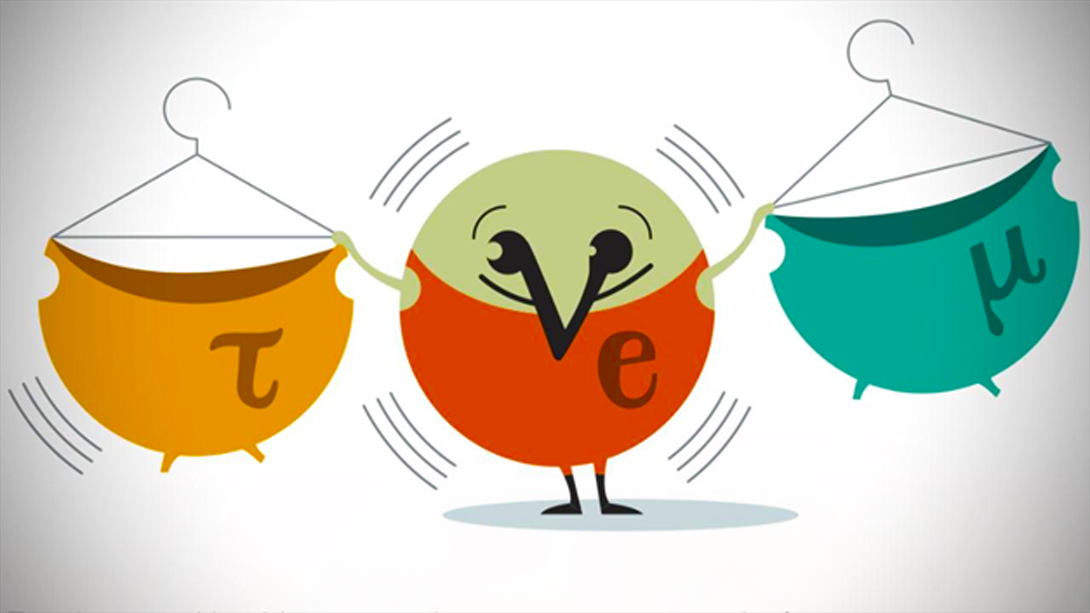

### Resumen

<font size="3">
El neutrino es un fermión ($s = \frac{1}{2}$) introducido por Wolfgang Pauli en 1931. Es un fermión que fue incluido en el modelo estándar de la física inicialmente sin masa. Sin embargo, se observaron oscilaciones de los mismos, fenómeno que implica que los neutrinos han de tener masa no nula (al menos dos de ellos) y que, además, ésta ha de ser diferente entre ellos. Este hecho es una de las cuestiones que aún quedan por explicar dentro del Modelo Estándar. 

En esta práctica se tratarán estas oscilaciones con el fin de entender cómo se producen y cómo esto explica las discrepancias entre los neutrinos que se esperaba que vinieran del Sol y de la atmósfera y los que fueron observados en varios experimentos a finales del siglo pasado. Por último, se realizará un estudio para analizar hasta qué punto un neutrino puede seguir considerándose de un cierto sabor leptónico debido a la interferencia de los autoestados de masa que lo componen.


<font size="3">

__Índice__
- Introducción
- Oscilaciones de neutrinos
- Oscilaciones para 2 sabores
- Oscilaciones para 3 sabores
- Conclusiones
- Referencias

# Introducción



<font size="3">

Recordemos que en Modelo Estándar tenemos neutrinos, y antineutrinos, de tres sabores, que se nombran en base al leptón de su correspondiente generación: $\nu_e, \nu_\mu, \nu_\tau$. Es importante tener en cuenta que esta notación corresponde a los autoestados de sabor, que son los que intervienen en los procesos de interacción. Además, en el Modelo Estándar los neutrinos y antineutrinos tienen quiralidades fijas bien definidas: $\nu_L, \bar{\nu}_R$. Del neutrino con quiralidad a derechas ($\nu_R$), que sería estéril, no hay todavía evidencias experimentales sólidas. 

Según se verá en las clases sobre el mecanismo de Higgs para la generación de masas para las partículas, debido precisamente a la quiralidad únicamente a izquierdas de los neutrinos, dicho mecanismo implicaría que éstos no tienen masas. Sin embargo, la detección de oscilaciones de neutrinos, como veremos en esta práctica, implica directamente que sí deben ser masivos (al menos dos de ellos). 

La física de neutrinos es una disciplina bastante reciente, desde el propio descubrimiento de estas partículas hasta la determinación de algunas de sus propiedades. Recordemos algunas fechas importantes:


1930: propuesta teórica del neutrino para explicar la desintegración $\beta$, $\qquad ^A_Z X \to ^A_{Z-1} Y + e^- + \bar{\nu}_e$ (Pauli)

1946: primera propuesta de detector de neutrinos por Pontecorvo

1956: experimento Reines-Cowan (desintegración $\beta$ inversa), $\qquad ^{37}Cl + \bar{\nu}_e \to ^{37}Ar + e^-$

1962: descubrimiento del $\nu_\mu$ en Brookhaven

1960/70's: problema de los neutrinos solares (déficit observado) en Homestake, y propuesta de las oscilaciones como solución

1998: medida de oscilaciones de neutrinos atmosféricos en SuperKamiokande

2000: descubrimiento del $\nu_\tau$ en DONUT

2000's: medidas definitivas de oscilaciones en SNO y SuperKamiokande, resolviendo el problema


A día de hoy, multitud de experimentos distintos trabajan midiendo con precisión las oscilaciones de neutrinos y todos los parámetros involucrados. Sin embargo, como se ha dicho, la existencia de masa no nula para estas partículas obtenida de las oscilaciones está en conflicto con la explicación para las masas que se da dentro del Modelo Estándar. Por tanto, aún quedan muchas cuestiones por explicar dentro de la física de neutrinos: naturaleza de la masa de los neutrinos (Dirac o Majorana), por qué ésta es mucho más pequeña que el resto de partículas del Modelo Estándar, jerarquía de masas entre los tres neutrinos (normal o invertida), neutrinos estériles, etc.

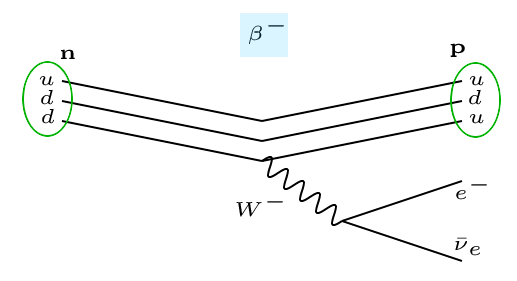



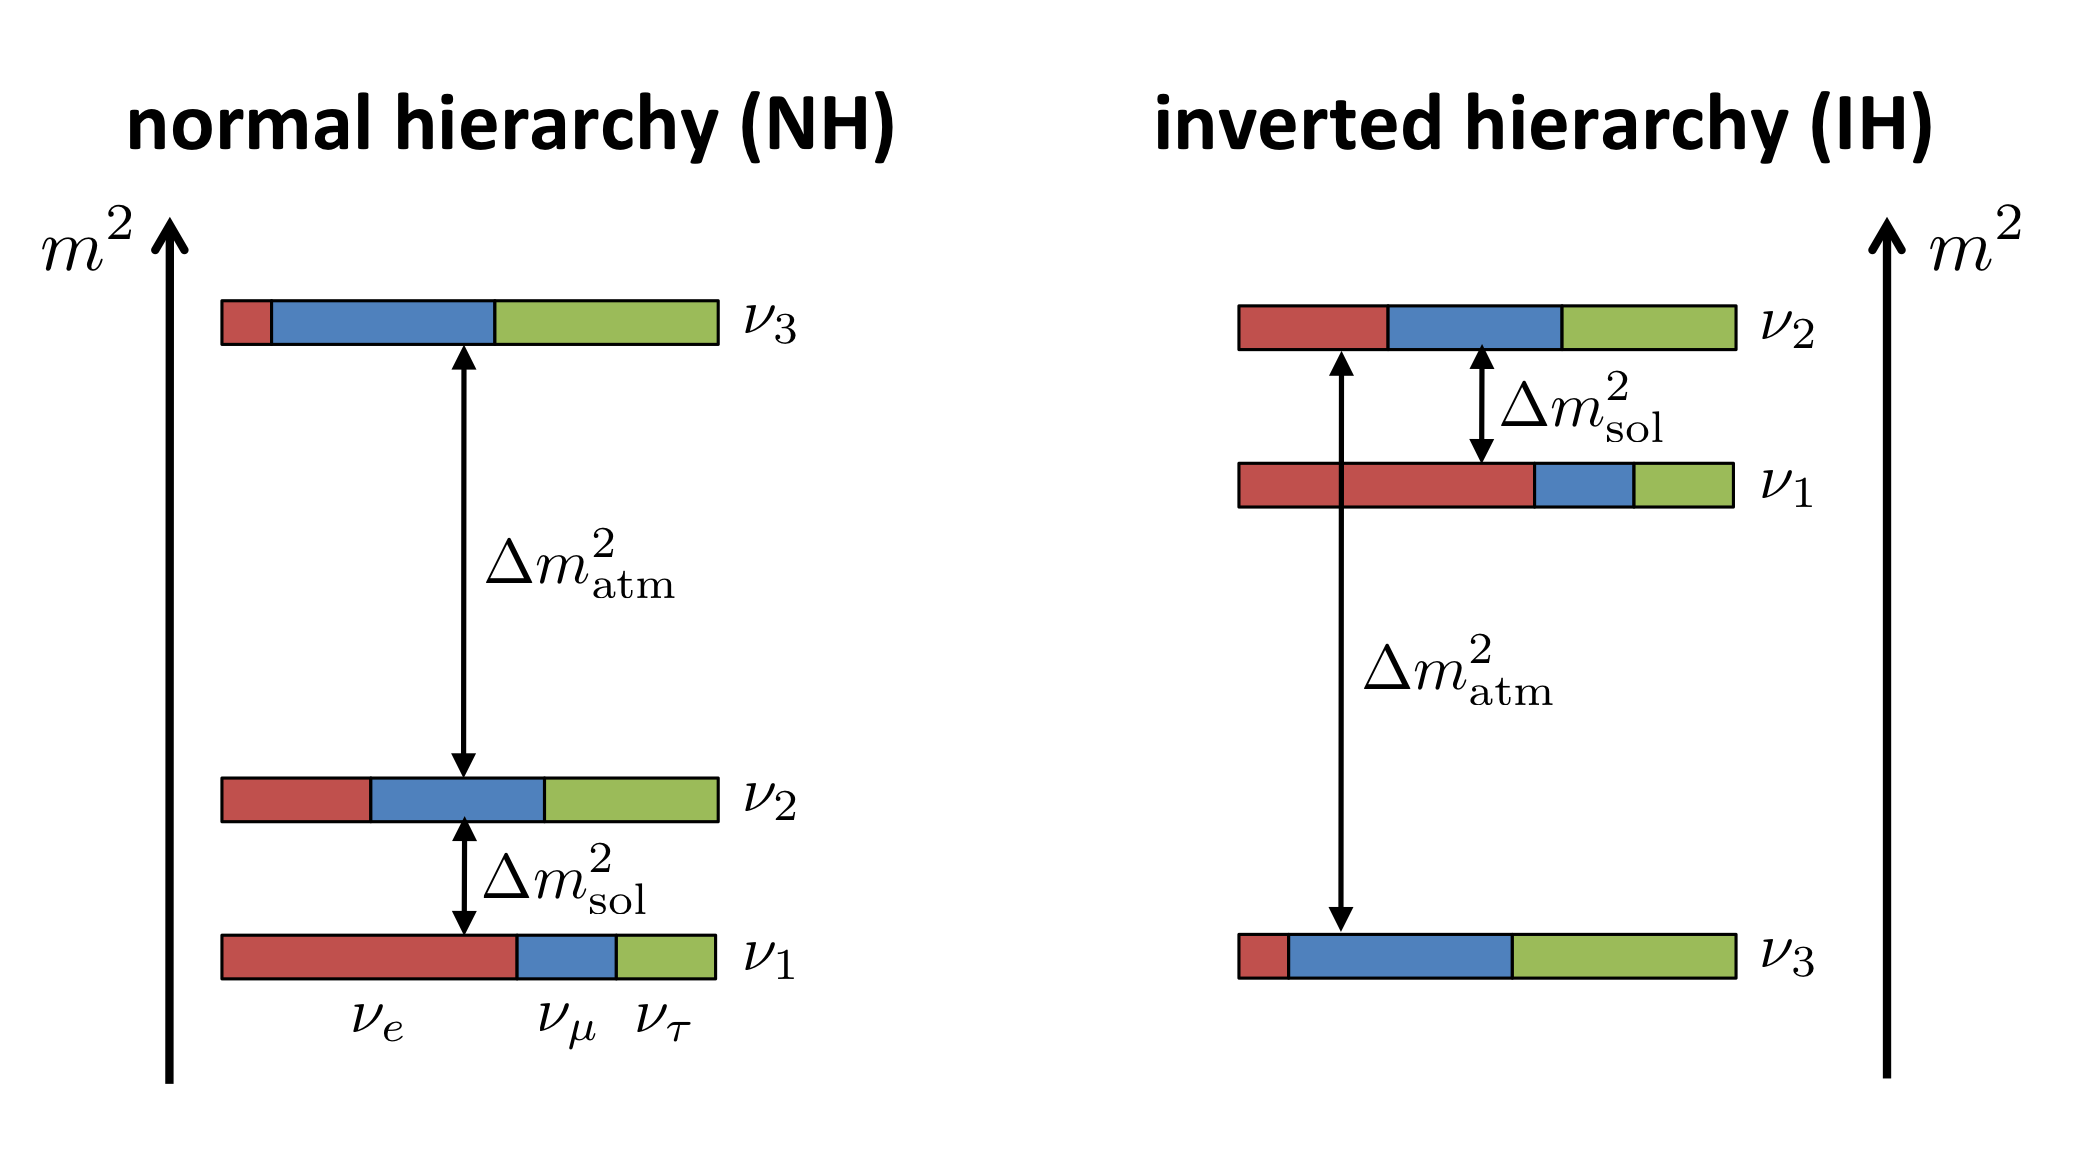

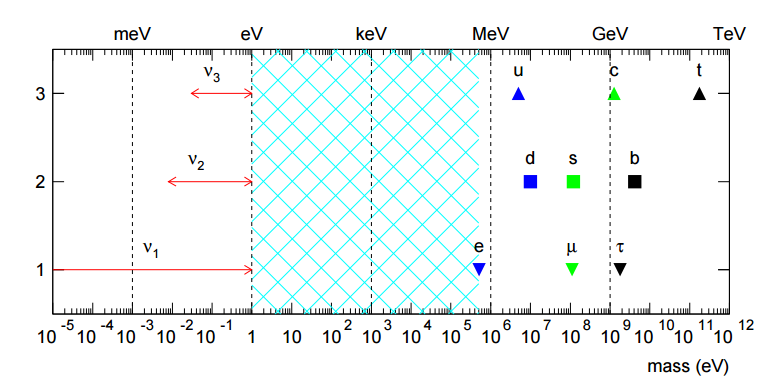

In [1]:
# Importación de librerías necesarias para la práctica:
# (véase la práctica 0 si se tienen dudas sobre estas librerías)

from sympy import *
init_printing()

import numpy as np

import matplotlib as mpl 
import matplotlib.pyplot as plt
%matplotlib inline

import time # Por si hace falta estimar el tiempo
start_time = time.time()


# Oscilaciones de neutrinos



<font size="3">

Para los neutrinos debemos distinguir dos bases de autoestados:
- los autoestados de sabor, que intervienen en las interacciones: $\nu_e, \nu_\mu, \nu_\tau$
- los autoestados de masa, que intervienen en la propagación: $\nu_1, \nu_2, \nu_3$

Entre ellos habrá una matriz que nos dará el cambio entre ambas bases:
$$ \nu_\ell = \sum_{j=1}^3 U_{\ell j} \nu_j \ .$$

Dicha matriz será unitaria, lo que nos fija el número de parámetros libres que emplearemos para describirla. 


Para estudiar el proceso de oscilaciones debemos tener en cuenta varios pasos. En primer lugar, un neutrino de un determinado sabor será producido en una interacción. Sin embargo, al hacer el cambio de base, dicho autoestado de sabor será una combinación de los tres autoestados de propagación. A continuación, se tendrá la propagación libre de los autoestados de masa; puesto que la propagación es libre en dicha base, será bastante sencillo obtener la propagación de cada uno. Finalmente, querremos detectar un neutrino, por tanto debemos volver a la base de sabores para tener la interacción con el detector. Así, como se habrán mezclado en la propagación, el neutrino que detectemos no tiene por qué ser del mismo sabor que el inicial. Tendremos que calcular la probabilidad de detectar cierto sabor habiéndose emitido inicialmente otro: $\mathcal{P}_{\nu_\ell \to \nu_{\ell'}}$.




## Matriz de oscilación

<font size="3">

¿Cuántos parámetros libres tenemos en el caso de matriz unitaria $n \times n$?
De los $n \times n$ parámetros reales de la matriz, debemos quitar $2n-1$, pues se puede absorber una fase en la definición del campo de cada quark más una fase global. Por tanto, nos quedan:

$\frac{1}{2}n(n-1)\ \rm{ángulos\ reales}$

$\frac{1}{2}(n-1)(n-2)\ \rm{fases}$  (Neutrinos de Dirac)

$\frac{1}{2} n (n-1)\ \rm{fases}$  (Neutrinos de Majorana)
    
    
¿Cuántos parámetros tendremos entonces para los casos de 2 y 3 generaciones? ¿Y si fueran 4?

In [2]:
# Calcular, para cada número de generaciones, cuántos parámetros habría de cada tipo.

N_angulos = lambda n: 1/2*n*(n-1)
N_fases_Dirac = lambda n: 1/2*(n-1)*(n-2)
N_fases_Majorana = lambda n: 1/2*n*(n-1)

# 2 generaciones (n=2)
print("2 generaciones\n")
print(f"Angulos reales: {N_angulos(2)}")
print(f"Fases (Dirac): {N_fases_Dirac(2)}")
print(f"Fases (Majorana): {N_fases_Majorana(2)}\n")

# 3 generaciones (n=3)
print("3 generaciones\n")
print(f"Angulos reales: {N_angulos(3)}")
print(f"Fases (Dirac): {N_fases_Dirac(3)}")
print(f"Fases (Majorana): {N_fases_Majorana(3)}")

2 generaciones

Angulos reales: 1.0
Fases (Dirac): 0.0
Fases (Majorana): 1.0

3 generaciones

Angulos reales: 3.0
Fases (Dirac): 1.0
Fases (Majorana): 3.0


<font size="3">


Para dos generaciones sólo tenemos 1 ángulo, es decir, una matriz de rotación $2\times2$.

In [3]:
# Definimos los parámetros a utilizar como símbolos de SymPy
# nota: indicamos que tienen valores reales porque luego hará falta tomar conjugados

th, th12, th13, th23, de, al21, al31 = symbols('theta theta_12 theta_13 theta_23 delta alpha_21 alpha_31', real=True)
th, th12, th13, th23, de, al21, al31

In [4]:
# algunos parámetros más (energías y tiempo)
E1, E2, E3, t = symbols('E_1 E_2 E_3 t', real=True)
E1, E2, E3, t

In [5]:
# y los nombres de los neutrinos
nu1, nu2, nu3, nue, numu, nutau = symbols('nu_1 nu_2 nu_3 nu_e nu_mu nu_tau', real=True)
nu1, nu2, nu3, nue, numu, nutau

<font size="3">


Para la matriz de oscilación, como hemos visto, tenemos distinto número de parámetros en función del número de neutrinos considerados. 

Puesto que el caso de dos neutrinos es útil, tanto como para hacer un cálculo analítico como para estudiar ciertos límites experimentales, definiremos las matrices también para este caso. En él, la matriz de cambio de base no es más que una matriz de rotación $2\times2$. 

Definimos también los vectores de neutrinos, en la base de sabor y en la de masas.


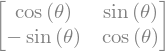

In [6]:
# Matriz de oscilación 2x2:

Rot_2 = Matrix([[cos(th), sin(th)], [-sin(th), cos(th)]])
M_2 = Rot_2 # en este caso, M_2 es simplemente la rotación

M_2

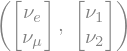

In [7]:
# Vectores de neutrinos en la base de masas y de sabores:

NU_sab2 = Matrix([[nue], [numu]])
NU_mas2 = Matrix([[nu1], [nu2]])

NU_sab2, NU_mas2

<font size="3">

La rotación en la base de sabor estará dada por la expresión, $$   \left(\begin{array}{c} \nu_e\\ \nu_\mu\end{array}\right)=M \left(\begin{array}{c} \nu_1\\ \nu_2\end{array}\right)\ . $$

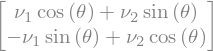

In [8]:
# IMPORTANTE: la multiplicación matricial en SymPy sí se hace con el operador *
# Calcular la rotación a la base de sabor.

NU_sab2p = M_2*NU_mas2
NU_sab2p

<font size="3">
Para el caso de $3\times3$, la matriz es más complicada, puesto que en ella intervienen más parámetros y además hay que considerar la inclusión de una (o tres) fases complejas. La parametrización estándar para esta matriz es bastante sencilla, ya que consiste simplemente en tomar tres matrices de rotación entre cada par de neutrinos. Para el caso de Majorana, se tendría que añadir una matriz diagonal adicional. 
    
_Nota: para los cálculos que realizaremos posteriormente en la práctica, todas las fases complejas serán tomadas como 0, de acuerdo con los resultados experimentales más recientes._

Así, para el caso $3\times3$, tendremos:

<font size="5">
$$   \left(\begin{array}{c} \nu_e\\ \nu_\mu\\ \nu_\tau \end{array}\right)=\left(\begin{array}{ccc} U_{e1}&U_{e2}&U_{e3}\\ U_{\mu1}&U_{\mu2}&U_{\mu3}\\ U_{\tau1}&U_{\tau2}&U_{\tau3} \end{array}\right)\left(\begin{array}{c} \nu_1\\ \nu_2\\ \nu_3\end{array}\right)\ . $$

<font size="3">
Esta matriz se conoce como PMNS, en honor a los científicos que propusieron esta hipótesis de oscilaciones: Pontecorvo, Maki, Nakagawa y Sakata.

<font size="3">

Habíamos visto que para el caso $n=3$ necesitábamos 3 ángulos y 1 fase. Por convención la fase se pone en la matriz 13. Para el caso de partículas de Majorana necesitaríamos añadir las fases adicionales.

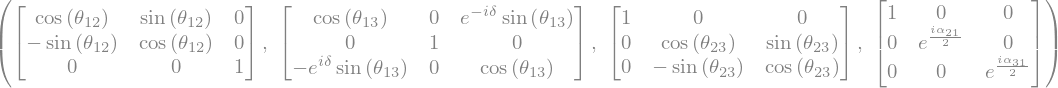

In [9]:
# Matriz de oscilación 3x3 (Matriz PMNS):
# Nota: Por convención, la fase se incluye en la matriz 13

Rot_12 = Matrix([[cos(th12), sin(th12), 0], [-sin(th12), cos(th12), 0], [0, 0, 1]])
Rot_13 = Matrix([[cos(th13), 0, sin(th13) * exp(-I * de)], [0, 1, 0], [-sin(th13) * exp(I * de), 0, cos(th13)]])
Rot_23 = Matrix([[1, 0, 0], [0, cos(th23), sin(th23)], [0, -sin(th23), cos(th23)]])

Maj = Matrix([[1, 0, 0], [0, exp(I / 2 * al21), 0], [0, 0, exp(I / 2 * al31)]])

Rot_12, Rot_13, Rot_23, Maj

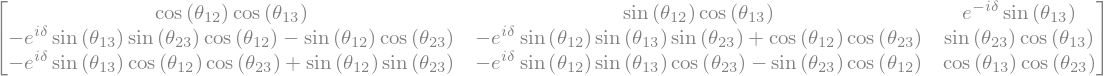

In [10]:
# Calcular la matriz PMNS: 23 * 13 * 12.

M_3 = Rot_23*Rot_13*Rot_12
M_3

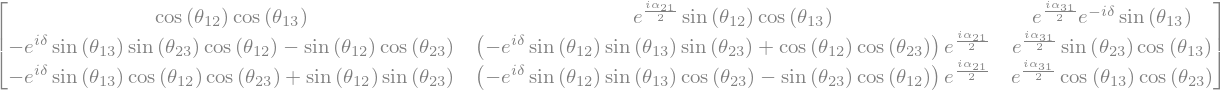

In [11]:
# Calcular la matriz para el caso de neutrinos de Majorana (multiplicando las fases por la derecha).

M_3Maj = M_3*Maj
M_3Maj

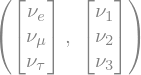

In [12]:
# Vectores de neutrinos en la base de masas y de sabores:

NU_sab3 = Matrix([[nue], [numu], [nutau]])
NU_mas3 = Matrix([[nu1], [nu2], [nu3]])

NU_sab3, NU_mas3

In [13]:
# definimos los nombres de los neutrinos como funciones (para estudiar la oscilación)

nu1f, nu2f, nu3f, nuef, numuf, nutauf = symbols('nu_1 nu_2 nu_3 nu_e nu_mu nu_tau', cls=Function, real=True)

symtofunc = [(nu1, nu1f(t)), (nu2, nu2f(t)), (nu3, nu3f(t)), (nue, nuef(t)), (numu, numuf(t)), (nutau, nutauf(t))]
symtofunc

# Oscilaciones para 2 sabores

<font size="3">

En primer lugar estudiaremos un caso en el que sólo tengamos dos sabores de neutrinos, por ejemplo, $\nu_e$ y $\nu_\mu$ (y por tanto sólo dos autoestados de masa $\nu_1$ y $\nu_2$). Así tendremos expresiones mucho más sencillas y nos será más fácil ver cómo la existencia de un ángulo de mezcla da lugar a oscilaciones de neutrinos. También veremos por qué éstas implican la existencia de masas no nulas para estas partículas.

_Nota: como debemos estudiar la propagación, hemos de definir todos los campos de neutrinos como funciones del tiempo o la distancia recorrida. Definimos también la energía $E_i$ de cada autoestado de masa._

_Nota: recordad que este caso, con solo 2 neutrinos, no corresponde al caso real del Modelo estándar (3 generaciones); sin embargo, sí va a proporcionar aproximaciones útiles en casos físicos, como se verá posteriormente para neutrinos solares y atmosféricos._

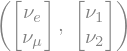

In [14]:
NU_sab2 = Matrix([[nue], [numu]])
NU_mas2 = Matrix([[nu1], [nu2]])

NU_sab2, NU_mas2

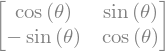

In [15]:
# Recordamos la matriz de oscilación

M_2

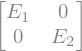

In [16]:
# Y la matriz de energías para la propagación (recordar que es diagonal en esta base)

EN_2 = Matrix([[E1, 0], [0, E2]])

EN_2

<font size="3">

En primer lugar, estudiamos la propagación libre de los autoestados de masa. Para ello resolvemos las correspondientes ecuaciones diferenciales, sencillas puesto que estamos en la base que diagonaliza la propagación. 

Hay que tener cuidado al imponer las condiciones iniciales, ya que como se ha visto, lo que se produce inicialmente es un autoestado de sabor, que es una mezcla de autoestados de masa. Por tanto, nunca tendremos una condición inicial que corresponda a un solo autoestado de masa.

_Nota: recuérdese que para ir de la base de sabor a la de masa, emplearemos la matriz inversa._

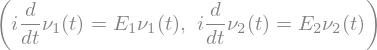

In [17]:
# Propagación libre: en los autoestados de MASA
# Ojo: SymPy da algunos problemas al mezclar matrices con ecuaciones diferenciales

prop2 = ( Eq( I * NU_mas2[0].subs(symtofunc).diff(t), (EN_2 * NU_mas2).subs(symtofunc)[0] ), 
         Eq( I * NU_mas2[1].subs(symtofunc).diff(t), (EN_2 * NU_mas2).subs(symtofunc)[1] ))
prop2  

In [18]:
# Resolvemos las ecuaciones de propagación:

sol2 = dsolve(prop2[0]), dsolve(prop2[1])
sol2

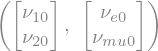

In [19]:
# Condiciones iniciales
# Lo hacemos a mano, pues aparentemente la versión actual de SymPy no las incluye :/

nu10, nu20, nu30, nue0, numu0, nutau0 = symbols('nu_10 nu_20 nu_30 nu_e0 nu_mu0 nu_tau0', real=True)

icsmas2 = Matrix([[nu10], [nu20]])
icssab2 = Matrix([[nue0], [numu0]])

icsmas2, icssab2

In [20]:
ctes2 = solve( sol2[0].subs(t, 0).rhs - icsmas2[0]) + solve( sol2[1].subs(t, 0).rhs - icsmas2[1] )

ctes2

In [21]:
sol2icsmas = sol2[0].subs(ctes2[0]), sol2[1].subs(ctes2[1])

sol2icsmas

<font size="3">

En general conocemos las condiciones iniciales en términos de sabor, no de masa, es decir,  $\nu_{e0}$ y $\nu_{\mu0}$. También sabemos que $ \nu^\mathrm{s}=M\nu^\mathrm{m}$, por lo que podemos invertir la matriz para conocer $\nu_{10}$ y $\nu_{20}$

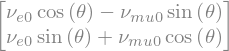

In [22]:
# Importante: las condiciones iniciales deben expresarse en la base de sabor
# pues los neutrinos habrán sido producidos en una interacción

icsbasis2 = (simplify(M_2.inv()) * icssab2)
icsbasis2

<font size="3">

Una vez conocidos  $\nu_{10}$ y $\nu_{20}$, podemos extraer  $\nu_{1}(t)$ y $\nu_{2}(t)$.

In [23]:
sol2icssab = sol2icsmas[0].subs(nu10, icsbasis2[0]), sol2icsmas[1].subs(nu20, icsbasis2[1])
sol2icssab

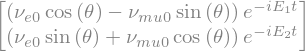

In [24]:
# Resultado final para la propagación en la base de masas, con condiciones iniciales

NU_mas2prop = Matrix( [[sol2icssab[0].rhs], [sol2icssab[1].rhs]] )
NU_mas2prop

<font size="3">

Con esto hemos obtenido la propagación libre de los autoestados de masas (con las condiciones iniciales adecuadas). 

A continuación, es necesario volver a la base de sabor, pues buscamos detectar los neutrinos con algún tipo de interacción. Para ello empleamos de nuevo la matriz de mezcla. 

Finalmente, una vez que tengamos los campos de los neutrinos expresados en la base adecuada, calculamos la probabilidad  de detectar un cierto sabor:

<font size="5">
$$\mathcal{P}_{\nu_\ell \to \nu_{\ell'}} (t) = |\nu_{\ell'}(t)|^2\ , \nu_{\ell0} = 1$$


<font size="3">

Para pasar de nuevo a la base de sabor, y así obtener $\nu_{e}(t)$ y $\nu_{\mu}(t)$, volvemos a usar la matriz de mezcla.

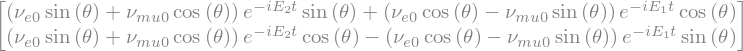

In [25]:
# Cambiamos de base para obtener la propagación en base de sabor:

NU_sab2prop = M_2 * NU_mas2prop
NU_sab2prop

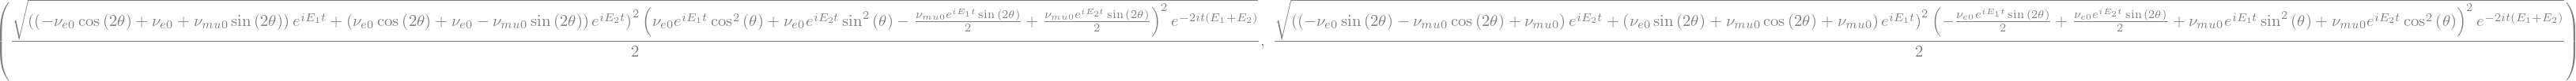

In [26]:
Prob_e = simplify(Abs(NU_sab2prop[0] ** 2 ))
Prob_mu = simplify(Abs(NU_sab2prop[1] ** 2 ))


Prob_e,Prob_mu

<font size="3">

Simplify tiene bastante dificultad para simplificar una expresión con exponenciales complejas. Esto se soluciona de manera bastante sencilla tomando la parte real de la siguiente expresión (la imaginaria es cero, por definición):

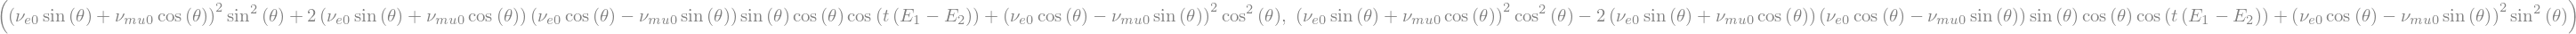

In [27]:
Prob_e = simplify(re(NU_sab2prop[0] * conjugate(NU_sab2prop[0] )))
Prob_mu = simplify(re(NU_sab2prop[1] * conjugate(NU_sab2prop[1] )))

Prob_e, Prob_mu

<font size="3">

Podemos facilmente comprobar que las dos probabilidades para cada caso deben sumar 1: $\mathcal{P}_{\nu_\ell \to \nu_{\ell'}} (t) + \mathcal{P}_{\nu_\ell \to \nu_{\ell}} (t) = 1$.

In [28]:
# Comprobar que la suma de probabilidades es 1 (el comando simplify ayuda):

simplify(Prob_e+Prob_mu) # = 1 por normalización del estado inicial

<font size="3">

    
Notad que $\nu_{e0}^2+\nu_{\mu0}^2=1$ ya que son la suma de las probabilidades iniciales.

<font size="3">

Hasta aquí hemos calculado las probabilidades de manera genérica para cualquier estado inicial. Definimos ahora los posibles casos iniciales, es decir, los posibles sabores del neutrino inicial.

In [29]:
# Completar.

icscasoe = [(nue0, 1), (numu0, 0)]
icscasomu = [(nue0, 0), (numu0, 1)]

icscasoe, icscasomu

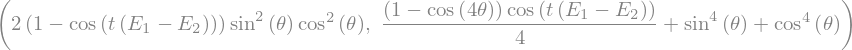

In [30]:
simplify(Prob_mu.subs(icscasoe)), simplify(Prob_e.subs(icscasoe))

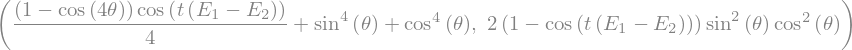

In [31]:
# Comprobar que las expresiones son análogas para el caso con neutrino mu inicial:

simplify(Prob_mu.subs(icscasomu)), simplify(Prob_e.subs(icscasomu))

<font size="3">

Podemos comprobar rápidamente que la probabilidad de ser neutrino electrónico más la probabilidad de ser muónico suma uno.

In [32]:
# Comprobar que la suma de probabilidades es 1 (para cada caso inicial):

print(simplify(simplify(Prob_mu.subs(icscasoe)) + simplify(Prob_e.subs(icscasoe))))
print(simplify(simplify(Prob_mu.subs(icscasomu)) + simplify(Prob_e.subs(icscasomu))))

1
1


<font size="3">

Con estas expresiones hemos obtenido la propagación en el tiempo de ambos neutrinos, y la probabilidad de detectar un sabor o el otro (a falta de simplificar el valor absoluto). 

Podemos expresar estas probabilidades de una forma más útil. Para ello tendremos en cuenta que estamos tratando con partículas relativistas (empleamos unidades naturales $\hbar=c=1$). En primer lugar, es más conveniente tener las expresiones en función de distancias en lugar de tiempos. En la aproximación ultrarrelativista $d\simeq t$. En segundo lugar, queremos expresar la diferencia de energías de los autoestados como una diferencia de masas:

$$ E^2 - |\vec{p}|^2 = m^2 \qquad\Rightarrow\qquad E\simeq |\vec{p}| + \frac{m^2}{2|\vec{p}|} \qquad \Rightarrow\qquad E_2 - E_1 \simeq \frac{m_2^2 - m_1^2}{2|\vec{p}|} \simeq \frac{m_2^2 - m_1^2}{2 E}\ ,$$

donde $E$ es la energía del neutrino inicial, y denotaremos la diferencia de masas al cuadrado como $\Delta m^2_{21} \equiv m_2^2 - m_1^2$. 



In [33]:
# Expresamos en distancias

E, d, DeltaM21, DeltaM31, DeltaM32 = symbols('E d Delta^2_M21 Delta^2_M31 Delta^2_M32', real=True)
E, d, DeltaM21, DeltaM31, DeltaM32

<font size="3">

Podemos entonces sustituir $E_1=E+\frac{\Delta m_{21}^2}{4E}$ y $E_2=E-\frac{\Delta m_{21}^2}{4E}$. Sympy simplifica mal cuando trata con exponenciales complejas. Podemos solucionarlo (de nuevo) tomando la parte real de la probabilidad (la imaginaria podemos comprobar que es 0).

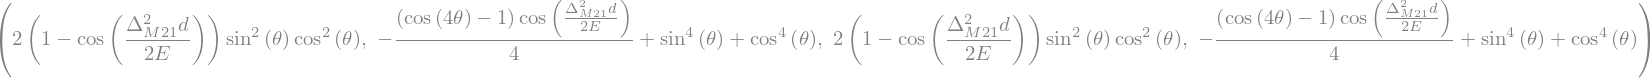

In [34]:
# Completar:

Prob_etomu = simplify(simplify(re(Prob_mu.subs(icscasoe))).subs(t,d).subs(E2, E - DeltaM21/ (4 * E)).subs(E1, E + DeltaM21/ (4 * E)))
Prob_etoe = simplify(simplify(re(Prob_e.subs(icscasoe))).subs(t,d).subs(E2, E - DeltaM21/ (4 * E)).subs(E1, E + DeltaM21/ (4 * E)))

Prob_mutoe = simplify(simplify(re(Prob_e.subs(icscasomu))).subs(t,d).subs(E2, E - DeltaM21/ (4 * E)).subs(E1, E + DeltaM21/ (4 * E)))
Prob_mutomu = simplify(simplify(re(Prob_mu.subs(icscasomu))).subs(t,d).subs(E2, E - DeltaM21/ (4 * E)).subs(E1, E + DeltaM21/ (4 * E)))

Prob_etomu, Prob_etoe, Prob_mutoe, Prob_mutomu

<font size="3">

Nótese que estas expresiones, a pesar de su aparente complejidad, son las mismas que encontramos en la bibliografía. Las diferencias únicamente se deben a la forma interna de simplificar de Python, pero la simplificación de las expresiones trigonométricas nos devolvería la expresión más conocida.

_Recordatorio_ : para obtener dichas probabilidades con la forma habitual, simplificaríamos analíticamente desde el principio empleando el siguiente truco:

$$ e^{i E_1 t} - e^{i E_2 t} = - e^{\frac{i}{2}(E_1 + E_2) t} \left( e^{\frac{i}{2}(E_2 - E_1) t} - e^{-\frac{i}{2}(E_2 - E_1) t} \right)\ , $$

correspondiendo la última resta de exponenciales un seno, y el resto son irrelevantes al tomar el módulo cuadrado, obteniéndose 

$$ 4 \sin^2\left(\frac{E_2 - E_1}{2} t\right)\ . $$

Combinando este resultado con la probabilidad obtenida anteriormente, y expresando el argumento del seno en masas y distancias, obtenemos la expresión habitual, por ejemplo:

$$ \mathcal{P}_{\nu_e\to\nu_\mu} = \sin^2(2\theta) \sin^2\left(\frac{\Delta m^2_{21}}{4E} d\right) \ .$$

Notemos en esta expresión que el primer seno es una constante dada por el valor del ángulo de mezcla, mientras que el segundo nos va a dar el carácter oscilatorio en función de la distancia. Es importante ver que esta oscilación sólo se tendrá si $\Delta m^2_{21} \neq 0$, y por tanto si se miden oscilaciones debe haber neutrinos con masa.

Para la probabilidad de supervivencia del $\nu_e$ tendríamos en este caso $\mathcal{P}_{\nu_e\to\nu_e} = 1 -\mathcal{P}_{\nu_e\to\nu_\mu}$. Véase que para el caso en el que inicialmente tuviésemos un $\nu_\mu$, las expresiones serían al revés. 

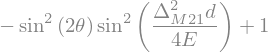

In [35]:
Probab = ( sin( 2 * th ) * sin( DeltaM21 * d / ( 4 * E ) ) ) ** 2

Prob_e = nue0 * (1 - Probab) + numu0 * Probab

Prob_etoe_2 = Prob_e.subs(icscasoe)

Prob_etoe_2

In [36]:
# Comprobamos que ambas expresiones son totalmente equivalentes.
# Por tanto podemos continuar trabajando con las expresiones de Python sin problema.

simplify(Prob_etoe - Prob_etoe_2)

<font size="3">

Una vez que tenemos todas las expresiones que necesitamos, procedemos a hacer algunos cálculos con los valores reales. Para ello sustituimos $\theta$ y $\Delta m^2$ por valores experimentales, que podemos consultar en [$\nu$fit:](http://www.nu-fit.org/?q=node/211), y tomamos un valor para la energía inicial. Atención a las unidades, y a expresar los ángulos en radianes para que sean reconocidos por Python; recordad que en unidades naturales:

$$ \hbar c=1 = 0.197 \ {\rm GeV \ fm} \ \Rightarrow 1 \ {\rm km} = 5.076 \cdot 10^9 \ {\rm eV}^{-1} \ .$$ 

Para visualizar las oscilaciones haremos una gráfica mostrando la probabilidad de supervivencia y la de conversión del neutrino inicial, en función de la distancia recorrida. Véase que si queremos evaluar una función analítica de SymPy en un array de distancias debemos convertir nuestros datos. Finalmente haremos la gráfica empleando Matplotlib.

In [37]:
# Valores para los datos: [E] = GeV, [Delta m^2] = eV^2

valores2 = [(th, np.radians(49.1)), (E, 1), (DeltaM21, 7.41 * 10 ** -3)]

In [38]:
# Caso 1: inicialmente tenemos un neutrino e
# Completar.

Probee_d = Prob_etoe.subs(valores2)
Probemu_d = Prob_etomu.subs(valores2)

Probmue_d = Prob_mutoe.subs(valores2)
Probmumu_d = Prob_mutomu.subs(valores2)

Probee_d, Probemu_d, Probmue_d, Probmumu_d

In [39]:
# Valores de distancia a evaluar: [d] = km (pero al evaluar en la probabilidad tiene que estar en GeV! recuerda que en la expresión aparece d/E)
# Creamos un array de datos
# Ojo al factor de conversión de unidades 

dist = 5.076 * np.linspace(0, 10 ** 3, 10 ** 4)
dist

array([0.00000000e+00, 5.07650765e-01, 1.01530153e+00, ...,
       5.07498470e+03, 5.07549235e+03, 5.07600000e+03], shape=(10000,))

In [40]:
# Evaluamos la probabilidad en esos valores de distancia
# Completar.

Probee = lambdify(d, Probee_d, "numpy")
Probemu = lambdify(d, Probemu_d, "numpy")

Probmue = lambdify(d, Probmue_d, "numpy")
Probmumu = lambdify(d, Probmumu_d, "numpy")

In [41]:
lambdify?

Signature:
lambdify(
    args,
    expr,
    modules=None,
    printer=None,
    use_imps=True,
    dummify=False,
    cse=False,
    docstring_limit=1000,
)
Docstring:
Convert a SymPy expression into a function that allows for fast
numeric evaluation.

.. warning::
   This function uses ``exec``, and thus should not be used on
   unsanitized input.

.. deprecated:: 1.7
   Passing a set for the *args* parameter is deprecated as sets are
   unordered. Use an ordered iterable such as a list or tuple.

Explanation

For example, to convert the SymPy expression ``sin(x) + cos(x)`` to an
equivalent NumPy function that numerically evaluates it:

>>> from sympy import sin, cos, symbols, lambdify
>>> import numpy as np
>>> x = symbols('x')
>>> expr = sin(x) + cos(x)
>>> expr
sin(x) + cos(x)
>>> f = lambdify(x, expr, 'numpy')
>>> a = np.array([1, 2])
>>> f(a)
[1.38177329 0.49315059]

The primary purpose of this function is to provide a bridge from SymPy
expressions to numerical libraries such as

In [41]:
# Se comprueba que son arrays completamente numéricos:

Probee(dist), Probemu(dist)

(array([1.        , 0.99999913, 0.99999653, ..., 0.99946511, 0.99950728,
        0.99954773], shape=(10000,)),
 array([0.00000000e+00, 8.66403974e-07, 3.46561283e-06, ...,
        5.34894412e-04, 4.92716580e-04, 4.52269813e-04], shape=(10000,)))

<font size="3">

Finalmente podemos representar los resultados obtenidos.

_Nota: podéis hacer las gráficas con el estilo que más os guste, pero recordar que éstas deben incluir siempre ejes, unidades, leyenda, etc., para que se pueda entender completamente la gráfica, además de tener un tamaño de letra legible para el informe._

Text(0.5, 0.98, 'Probabilidad de supervivencia del neutrino electrónico tras propagarse una distancia d (con E=1)')

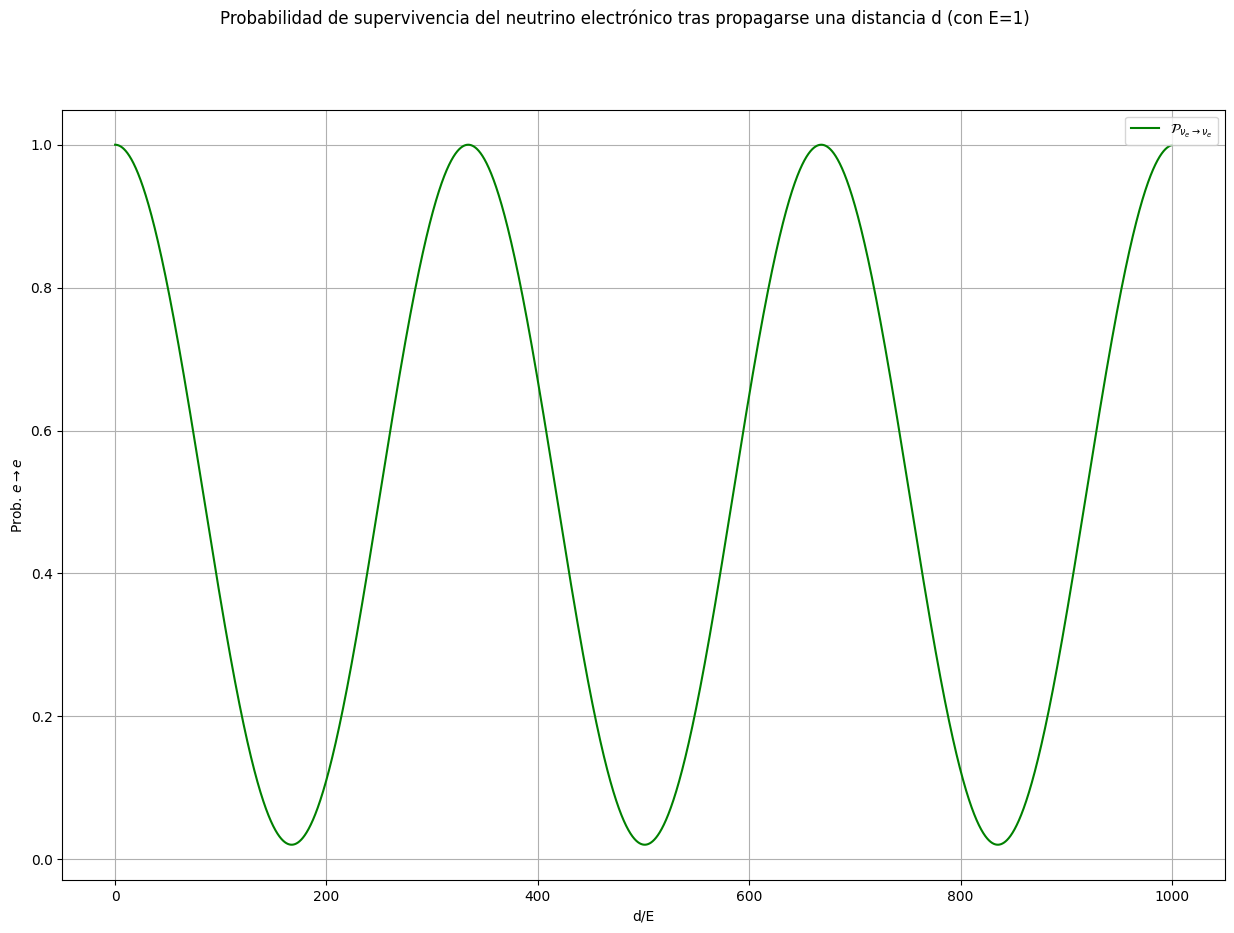

In [44]:
# Creamos un plot: Probee y Probemu frente a dist
# recordad el factor de conversión en las distancias: ax.plot(dist / 5.076, ...)
# Añadir: labels, etiquetas de ejes, grid, título, leyenda (véase opciones de plots en la práctica 0)
# para incluir texto LaTeX: label=r'$\mathcal{P}_{\nu_e\to\nu_e}$'
#fig.suptitle(" ... " + r'$...$', fontsize = ...)


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_e\to\nu_e}$') 

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("Prob. " + r'$e\to e$')
ax.legend()

fig.suptitle("Probabilidad de supervivencia del neutrino electrónico tras propagarse una distancia d (con E=1)")


_Nota: recordad que, para representar en las unidades adecuadas, dividimos entre el factor de conversión de unidades como se comentó anteriormente._

Text(0.5, 0.98, 'Probabilidad de supervivencia del neutrino muónico tras propagarse una distancia d (con E=1)')

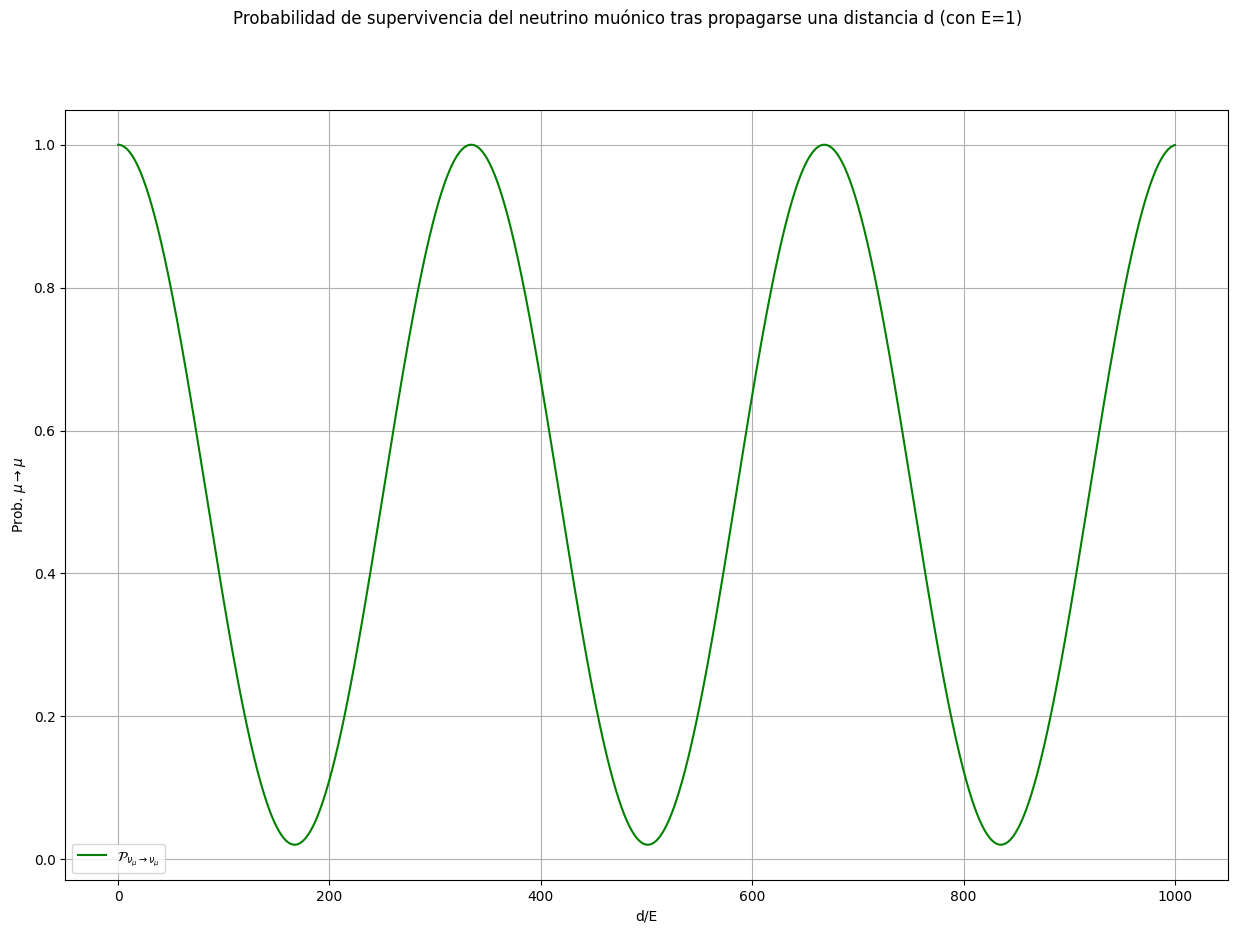

In [45]:
# Realizar la gráfica correspondiente al caso con un neutrino mu inicial:

fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probmumu(dist), 'g-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\mu}}$') 

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("Prob. " + r'$\mu\to \mu$')
ax.legend()

fig.suptitle("Probabilidad de supervivencia del neutrino muónico tras propagarse una distancia d (con E=1)")

**Nota:** más interesante que ver la probabilidad de supervivencia de un  neutrino electrónico y uno muónico, que parece ser la misma, es ver conjuntamente la probabilidad de $e\to \mu$ y de $e\to e$ cuando inicialmente teníamos un estado de neutrino electrónico en la base de sabor. Lo vemos:

Text(0.5, 0.98, 'Oscilaciones del neutrino electrónico')

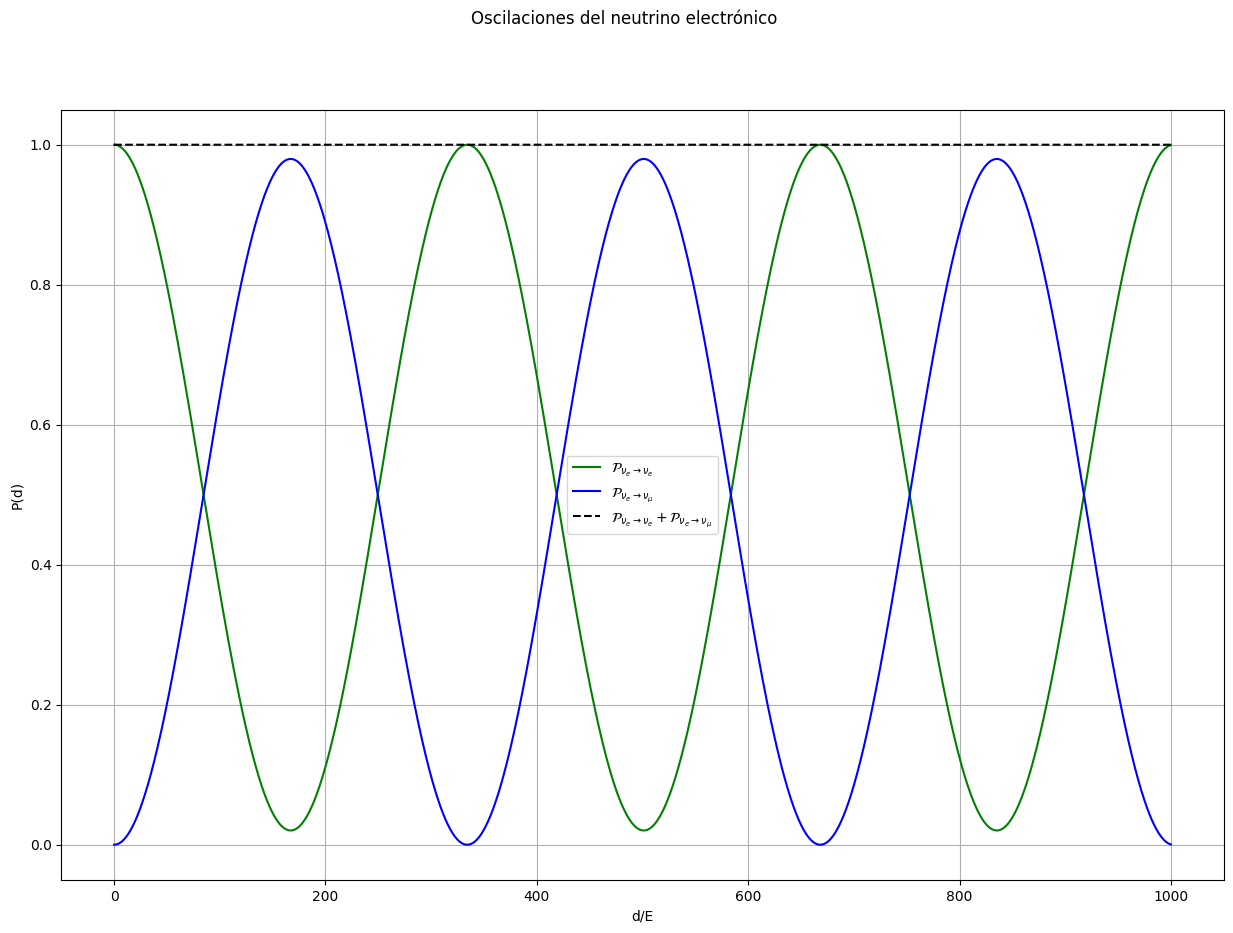

In [47]:
fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_e\to\nu_e}$') 
ax.plot(dist / 5.076, Probemu(dist), 'b-', label=r'$\mathcal{P}_{\nu_e\to\nu_{\mu}}$')
ax.plot(dist / 5.076, Probee(dist) + Probemu(dist), 'k--', label=r'$\mathcal{P}_{\nu_e\to\nu_e} + \mathcal{P}_{\nu_e\to\nu_{\mu}}$')


x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d)")
ax.legend()

fig.suptitle("Oscilaciones del neutrino electrónico") 

# Oscilaciones para 3 sabores

<font size="3">

En segundo lugar estudiaremos el caso general en el que tenemos los tres sabores de neutrinos, $\nu_e, \nu_\mu$ y $\nu_\tau$ (y por tanto tres autoestados de masa $\nu_1, \nu_2$ y $\nu_3$). En este caso, las expresiones son más complicadas pues las oscilaciones se darán entre los tres mezclados, y el comportamiento sinusoidal será más complejo. Sin embargo, las implicaciones son las mismas.  

_Nota: veáse que en el caso general, además de los tres ángulos de mezcla, tendremos una fase para neutrinos de Dirac (si hay violación CP) y dos más para neutrinos de Majorana. Las evidencias experimentales son compatibles con que todas estas fases sean nulas, por lo que no influirán en los resultados de la práctica._

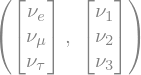

In [48]:
# Definimos las variables para 3 neutrinos
# Completar.

NU_sab3 = Matrix([[nue], [numu], [nutau]])
NU_mas3 = Matrix([[nu1], [nu2], [nu3]])

NU_sab3, NU_mas3

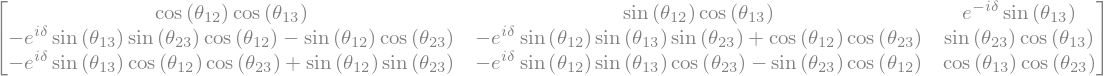

In [49]:
# Recordamos la matriz de oscilación (no trataremos la parte de Majorana).

M_3

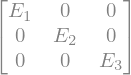

In [50]:
# Y la matriz de energías para la propagación (recordar que es diagonal en esta base)
# Completar.

EN_3 = Matrix([[E1, 0, 0], [0, E2, 0], [0, 0, E3]])

EN_3

<font size="3">

Al igual que en el caso anterior, estudiamos la propagación libre de los autoestados de masa. Para ello resolvemos las correspondientes ecuaciones diferenciales, sencillas puesto que estamos en la base que diagonaliza la propagación. 

Recordad aplicar las condiciones iniciales en la base correcta.

_Nota: recuérdese que para ir de la base de sabor a la de masa, emplearemos la matriz inversa._

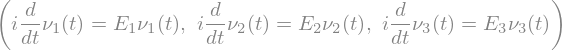

In [51]:
# Propagación libre: en los autoestados de MASA
# Escribir las ecuaciones diferenciales de propagación.

prop3 = ( Eq( I * NU_mas3[0].subs(symtofunc).diff(t), (EN_3 * NU_mas3).subs(symtofunc)[0] ), 
         Eq( I * NU_mas3[1].subs(symtofunc).diff(t), (EN_3 * NU_mas3).subs(symtofunc)[1] ),
        Eq( I * NU_mas3[2].subs(symtofunc).diff(t), (EN_3 * NU_mas3).subs(symtofunc)[2] ))
prop3

In [52]:
# Calcular la solución de estas ecuaciones con dsolve.

sol3 = dsolve(prop3[0]), dsolve(prop3[1]), dsolve(prop3[2])

sol3

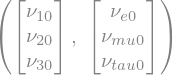

In [53]:
# Condiciones iniciales.
# Completar:

icsmas3 = Matrix([[nu10], [nu20], [nu30]])
icssab3 = Matrix([[nue0], [numu0], [nutau0]])

icsmas3, icssab3

In [54]:
# Calcular las condiciones iniciales.
# Completar.

ctes3 = solve( sol3[0].subs(t, 0).rhs - icsmas3[0]) + solve( sol3[1].subs(t, 0).rhs - icsmas3[1] ) + solve( sol3[2].subs(t, 0).rhs - icsmas3[2] )

ctes3

In [55]:
# Incluir las condiciones iniciales en la solución.
# Completar.

sol3icsmas = sol3[0].subs(ctes3[0]), sol3[1].subs(ctes3[1]), sol3[2].subs(ctes3[2])

sol3icsmas

<font size="3">

Como se ha visto en el caso anterior, las expresiones completamente analíticas son bastante complicadas, y en este caso más al ser una matriz con más entradas. Por tanto, para simplificar los cálculos, metemos los valores experimentales de los ángulos de mezcla en la matriz y trabajaremos con expresiones numéricas más simples.

In [56]:
valores = [(th12, np.radians(33.41)), (th13, np.radians(8.54)), (th23, np.radians(49.1)), (de, 0)]
valores

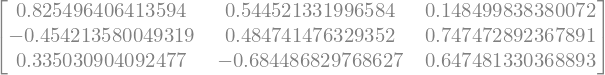

In [57]:
# Redefinimos la matriz con sus valores numéricos.

M_3 = M_3.subs(valores)

M_3

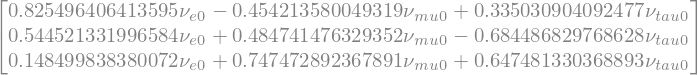

In [58]:
# Condiciones iniciales en la base de sabor.
# Nótese que la expresión depende en este caso de las tres condiciones iniciales.
# Cada valor numérico equivale a la correspondiente combinación de ángulos de mezcla.

icsbasis3 = (simplify(M_3.inv()) * icssab3)

icsbasis3

In [59]:
# Completar.


sol3icssab = sol3icsmas[0].subs(nu10, icsbasis3[0]), sol3icsmas[1].subs(nu20, icsbasis3[1]), sol3icsmas[2].subs(nu30, icsbasis3[2])

sol3icssab

<font size="3">

    
Calculamos cada $\nu_i (t)$.

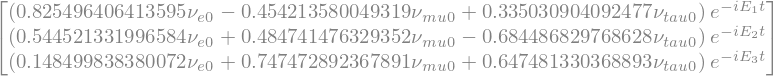

In [60]:
# Resultado final para la propagación en la base de masas, con condiciones iniciales.
# Completar.


NU_mas3prop = Matrix( [[sol3icssab[0].rhs], [sol3icssab[1].rhs], [sol3icssab[2].rhs]] )

NU_mas3prop

<font size="3">

Con esto hemos obtenido la propagación libre de los autoestados de masas, por lo que volvemos de nuevo a la base de sabor.

Finalmente, una vez que tengamos los campos de los neutrinos expresados en la base adecuada, calculamos la probabilidad  de detectar un cierto sabor. Para cada caso inicial, las probabilidades de detección de cada sabor deben sumar $1$, pero en este caso tenemos tres probabilidades por lo que habrá que hallar cada una explícitamente.

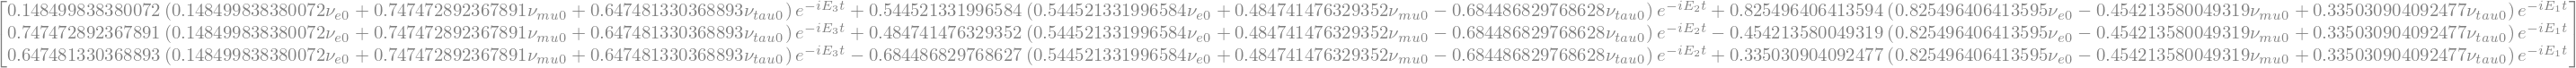

In [61]:
# Cambiamos de base para obtener la propagación en base de sabor:
# Completar.

NU_sab3prop = M_3 * NU_mas3prop

NU_sab3prop

<font size="3">

Finalmente, para llegar a las expresiones habituales sustituimos las variables $E_i$ por las diferencias de masas $\Delta m^2_{ij}$ y el tiempo por la distancia $d$, análogamente al cálculo de 2 sabores.

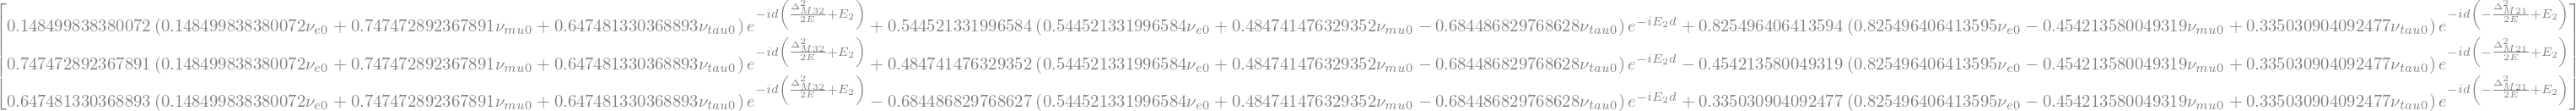

In [62]:
NU_sab3prop = NU_sab3prop.subs(t,d).subs(E1, E2 - DeltaM21/ (2 * E)).subs(E3, E2 + DeltaM32/ (2 * E))

NU_sab3prop

<font size="3">

Una vez conocida la evolución de cada uno de los $\nu_\ell (t)$ podemos calcular la probabilidad

$$\mathcal{P}_{\nu_\ell \to \nu_{\ell'}} (t) = |\nu_{\ell'}(t)|^2\ .$$
    
De nuevo repetimos el truco que usamos para $n=2$ para facilitar la simplificación (tomar la parte real del producto $\nu \nu^*$).



In [63]:
Prob3_e = simplify(re(NU_sab3prop[0] * conjugate(NU_sab3prop[0])))
Prob3_mu = simplify(re(NU_sab3prop[1] * conjugate(NU_sab3prop[1])))
Prob3_tau = simplify(re(NU_sab3prop[2] * conjugate(NU_sab3prop[2])))

# No simplificamos más porque lleva mucho tiempo y no hace falta para los siguientes cálculos.

Prob3_e, Prob3_mu, Prob3_tau

<font size="3">

Podemos comprobar que la suma de las tres probabilidades da 1. Utilizamos nsimplify para eliminar los términos con coeficientes extremadamente pequeños (menores de $10 ^{-10}$, que realmente son cero). Recordad que la suma de probabilidades iniciales es 1 por definición.

In [64]:
nsimplify(expand(Prob3_e + Prob3_mu + Prob3_tau), tolerance = 1e-10) # = 1 por normalización

<font size="3">

Hasta ahora hemos calculado la probabilidad en función de las condiciones iniciales. Calculamos ahora la probabilidad de encontrar un neutrino de un determinado sabor a cierta distancia $d$ sabiendo que al inicio era electrónico, muónico o tauónico.

In [65]:
# Calcular las condiciones iniciales.
icscasoe = [(nue0, 1), (numu0, 0), (nutau0, 0)]
icscasomu = [(nue0, 0), (numu0, 1), (nutau0, 0)]
icscasotau = [(nue0, 0), (numu0, 0), (nutau0, 1)]

icscasoe, icscasomu, icscasotau

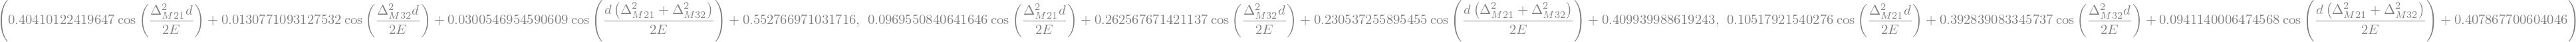

In [66]:
# Finalmente calculamos la probabilidad nu_l -> nu_l' para todos los casos, con sus correspondientes condiciones iniciales:
# Completar.

Prob3_ee = simplify(re(Prob3_e).subs(icscasoe))
Prob3_emu = simplify(re(Prob3_mu).subs(icscasoe))
Prob3_etau = simplify(re(Prob3_tau).subs(icscasoe))

Prob3_mue = simplify(re(Prob3_e).subs(icscasomu))
Prob3_mumu = simplify(re(Prob3_mu).subs(icscasomu))
Prob3_mutau = simplify(re(Prob3_tau).subs(icscasomu))

Prob3_taue = simplify(re(Prob3_e).subs(icscasotau))
Prob3_taumu = simplify(re(Prob3_mu).subs(icscasotau))
Prob3_tautau = simplify(re(Prob3_tau).subs(icscasotau))

Prob3_ee, Prob3_mumu, Prob3_tautau

<font size="3">

Notamos que estas expresiones ya tienen la forma adecuada, cada una es una cierta combinación de factores numéricos (correspondientes a los ángulos de mezcla) con su correspondiente factor trigonométrico en función de una diferencia de masas $\Delta m^2_{ij}$, la distancia y la energía inicial. Véase que $\Delta m^2_{21} + \Delta m^2_{32} = \Delta m^2_{31}$, por tanto cada término corresponde a una sola diferencia de masas (queda expresada así debido a la simplificación de Python).

<font size="3">

Podríamos haber calculado estas probabilidades también a partir de la expresión habitual de la bibliografía. De nuevo podemos ver que el resultado es el mismo, pero conocer esta expresión analítica nos vendrá bien para entender los apartados posteriores.

$$ \mathcal{P}_{\nu_\alpha\to\nu_\beta} = |\langle\nu_\beta|\nu_\alpha\rangle|^2 = | \sum_{j=1}^3 U^*_{\alpha j} U_{\beta j} e^{-i \frac{m_j^2 d}{2 E} }  |^2 = $$

$$ = \delta_{\alpha_\beta} - 4 \sum_{i>j} Re(U^*_{\alpha i} U_{\beta i} U_{\alpha j} U^*_{\beta j}) \sin^2\left(\frac{\Delta m^2_{ij}}{4E} d\right) + 2 \sum_{i>j} Im(U^*_{\alpha i} U_{\beta i} U_{\alpha j} U^*_{\beta j}) \sin^2\left(\frac{\Delta m^2_{ij}}{2E} d\right) \ .$$


En esta expresión, podemos observar la expresión de los factores numéricos que salen por combinación de elementos de la matriz PMNS, que incluirán una combinación de senos y cosenos de los tres ángulos de mezcla, que corresponde a la parte constante encontrada que depende de los valores experimentales de dichos ángulos. Por otra parte, los términos sinusoidales que incluyen la diferencia de masas son los que dan la oscilación en función de la distancia. 
    
De esta expresión es automático observar que el comportamiento es análogo al caso con 2 neutrinos, solo que como tenemos un sumatorio vamos a tener una combinación de varios senos que harán la oscilación más complicada. Nótese que el segundo sumatorio, que incluye la parte imaginaria, sólo sería distinto de cero si hay violación CP, es decir, si hubiese un $\delta$ no nulo.

<font size="3">

Comprobamos que la suma de todas las probabilidades da 1 (dentro de la precisión); utilizamos de nuevo nsimplify (¿qué sucede si usamos la simplificación analítica en lugar de la numérica?).

**Respuesta:** si simplificamos de forma analítica, con toda seguridad la suma de probabilidades no dará 1 debido al error de las cantidades experimentales que hemos introducido al inicio de esta sección, que se habrán propagado por nuestros cálculos. Sin embargo, como por conservación de probabilidad la suma de las 3 probabilidades debe dar 1, es de esperar que haya cancelaciones muy fuertes, de modo que quedará: $\displaystyle\sum_{i=1}^3P_i=1+\varepsilon$, donde $\varepsilon << 1$ es el resultado de dichas cancelaciones. Es por esto que simplificamos numéricamente con nsimplify

In [67]:
# Comprobar que la suma de probabilidades es 1, para cada caso inicial nu_e, nu_mu y nu_tau.
# Calcular:

# Caso A: nu_e-->algo
print(nsimplify(Prob3_ee + Prob3_emu + Prob3_etau, tolerance = 1e-10))

# Caso B: nu_mu-->algo
print(nsimplify(Prob3_mue + Prob3_mumu + Prob3_mutau, tolerance = 1e-10))

# Caso C: nu_tau-->algo
print(nsimplify(Prob3_taue + Prob3_taumu + Prob3_tautau, tolerance = 1e-10))

1
1
1


<font size="3">

Vamos ahora a tratar de representar las tres probabilidades como función de la distancia $d$. Para ello necesitamos fijar los valores de las energías y masas con sus valores numéricos. Y de nuevo, definimos un array de distancias (en km).

In [68]:
# Valores para los datos: [E] = GeV, [Delta m^2] = eV^2

valores3 = [(E,1), (DeltaM21, 7.41 * 10 ** -5), (DeltaM31, 2.51 * 10 ** -3), (DeltaM32, 2.44 * 10 ** -3)]

In [69]:
# Valores de distancia a evaluar: [d] = km
# creamos un array de datos
# Ojo al factor de conversión de unidades

dist = 5.076 * np.linspace(0, 5 * 10 ** 4, 10 ** 5)

dist

array([0.00000000e+00, 2.53802538e+00, 5.07605076e+00, ...,
       2.53794924e+05, 2.53797462e+05, 2.53800000e+05], shape=(100000,))

_Nota: recordad correr el notebook teniendo cuidado con el orden, ya que estamos llamando "dist" a varias distancias distintas, por lo que el array se sobreescribe con cada evaluación._

In [70]:
# Completar las probabilidades de oscilación.
# Caso con un neutrino electrónico inicial.

Probee_d = Prob3_ee.subs(valores3)
Probemu_d = Prob3_emu.subs(valores3)
Probetau_d = Prob3_etau.subs(valores3)

Probee = lambdify(d, Probee_d, "numpy")
Probemu = lambdify(d, Probemu_d, "numpy")
Probetau = lambdify(d, Probetau_d, "numpy")

Probee(dist), Probemu(dist), Probetau(dist)

(array([1.        , 0.99999978, 0.99999913, ..., 0.15120728, 0.15126127,
        0.15131524], shape=(100000,)),
 array([-1.11022302e-16,  1.43607755e-07,  5.74429400e-07, ...,
         3.96448287e-01,  3.96008275e-01,  3.95568503e-01], shape=(100000,)),
 array([0.00000000e+00, 7.38284827e-08, 2.95313392e-07, ...,
        4.52344435e-01, 4.52730456e-01, 4.53116258e-01], shape=(100000,)))

Text(0.5, 0.98, 'Oscilaciones de $\\nu_e$ (3 familias leptónicas)')

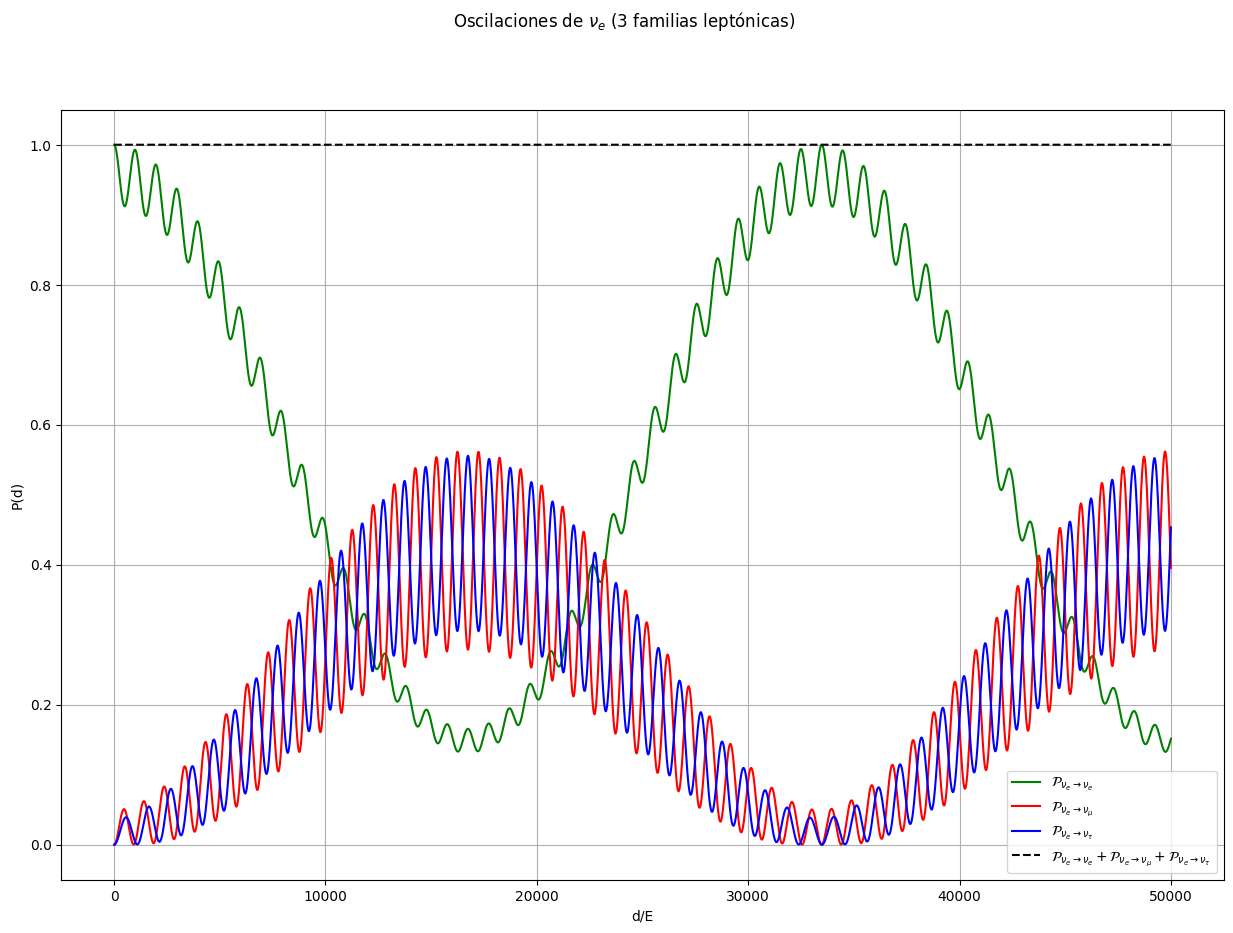

In [72]:
# Creamos un plot:
# Recordad el factor de conversión en las distancias


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_e\to\nu_e}$') 
ax.plot(dist / 5.076, Probemu(dist), 'r-', label=r'$\mathcal{P}_{\nu_e\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probetau(dist), 'b-', label=r'$\mathcal{P}_{\nu_e\to\nu_{\tau}}$')
ax.plot(dist / 5.076, Probee(dist) + Probemu(dist) + Probetau(dist), 'k--', label=r'$\mathcal{P}_{\nu_e\to\nu_e} + \mathcal{P}_{\nu_e\to\nu_{\mu}} + \mathcal{P}_{\nu_e\to\nu_{\tau}}$') 

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_e$ (3 familias leptónicas)") 

<font size="3">

¿Qué pasaría en los otros dos casos, partiendo de un neutrino mu o tau? Representad las figuras correspondientes a cada caso.

Text(0.5, 0.98, 'Oscilaciones de $\\nu_\\mu$ (3 familias leptónicas)')

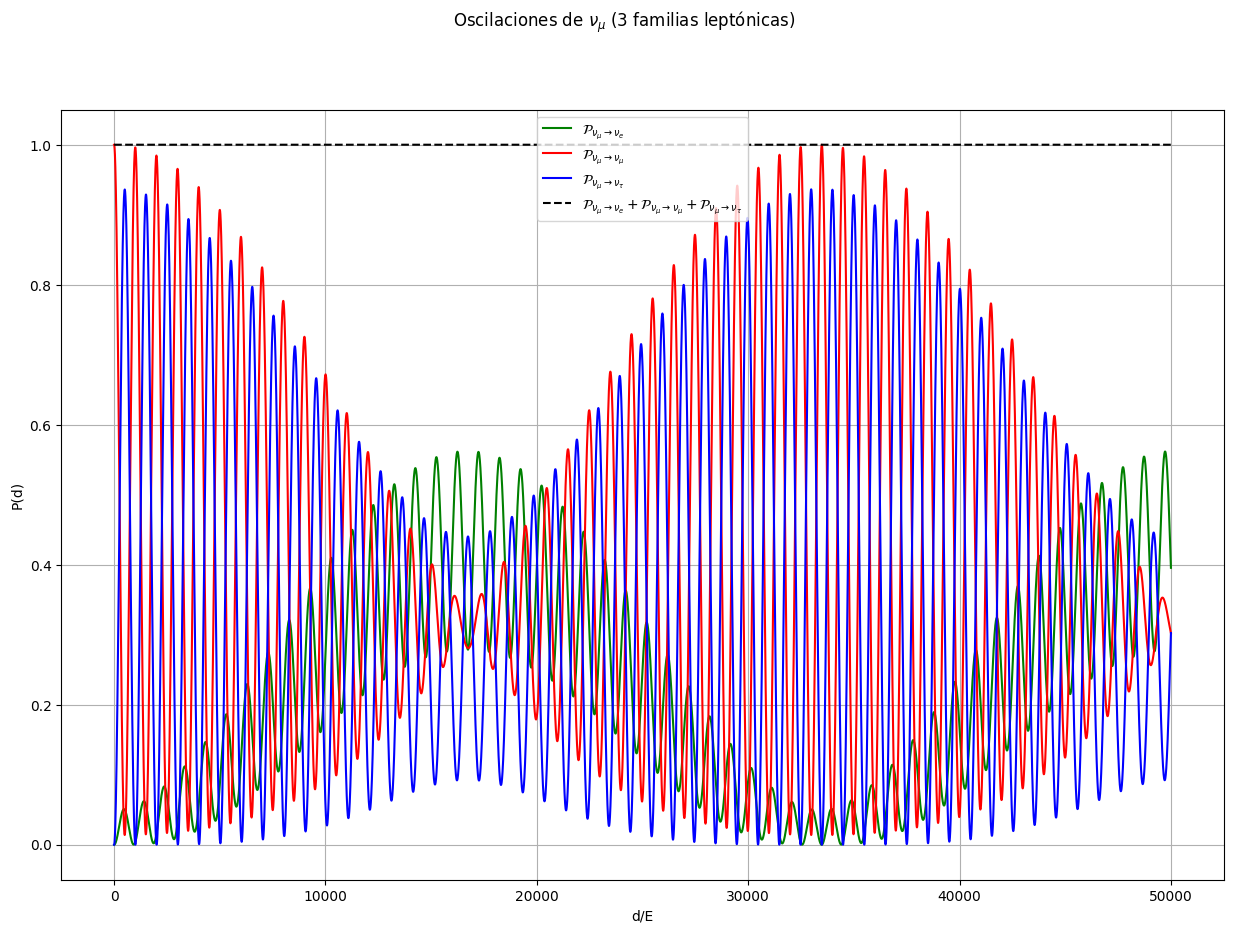

In [83]:
# Completar las probabilidades de oscilación.
# Caso con un neutrino mu inicial.


Probmue_d = Prob3_mue.subs(valores3)
Probmumu_d = Prob3_mumu.subs(valores3)
Probmutau_d = Prob3_mutau.subs(valores3)

Probmue = lambdify(d, Probmue_d, "numpy")
Probmumu = lambdify(d, Probmumu_d, "numpy")
Probmutau = lambdify(d, Probmutau_d, "numpy")


# Creamos un plot:
# Recordad el factor de conversión en las distancias


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probmue(dist), 'g-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_e}$') 
ax.plot(dist / 5.076, Probmumu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probmutau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\tau}}$')
ax.plot(dist / 5.076, Probmue(dist) + Probmumu(dist) + Probmutau(dist), 'k--', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_e} + \mathcal{P}_{\nu_{\mu}\to\nu_{\mu}} + \mathcal{P}_{\nu_{\mu}\to\nu_{\tau}}$') 

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d)")
ax.legend(loc="upper center")

fig.suptitle("Oscilaciones de $\\nu_\\mu$ (3 familias leptónicas)") 



Text(0.5, 0.98, 'Oscilaciones de $\\nu_\\tau$ (3 familias leptónicas)')

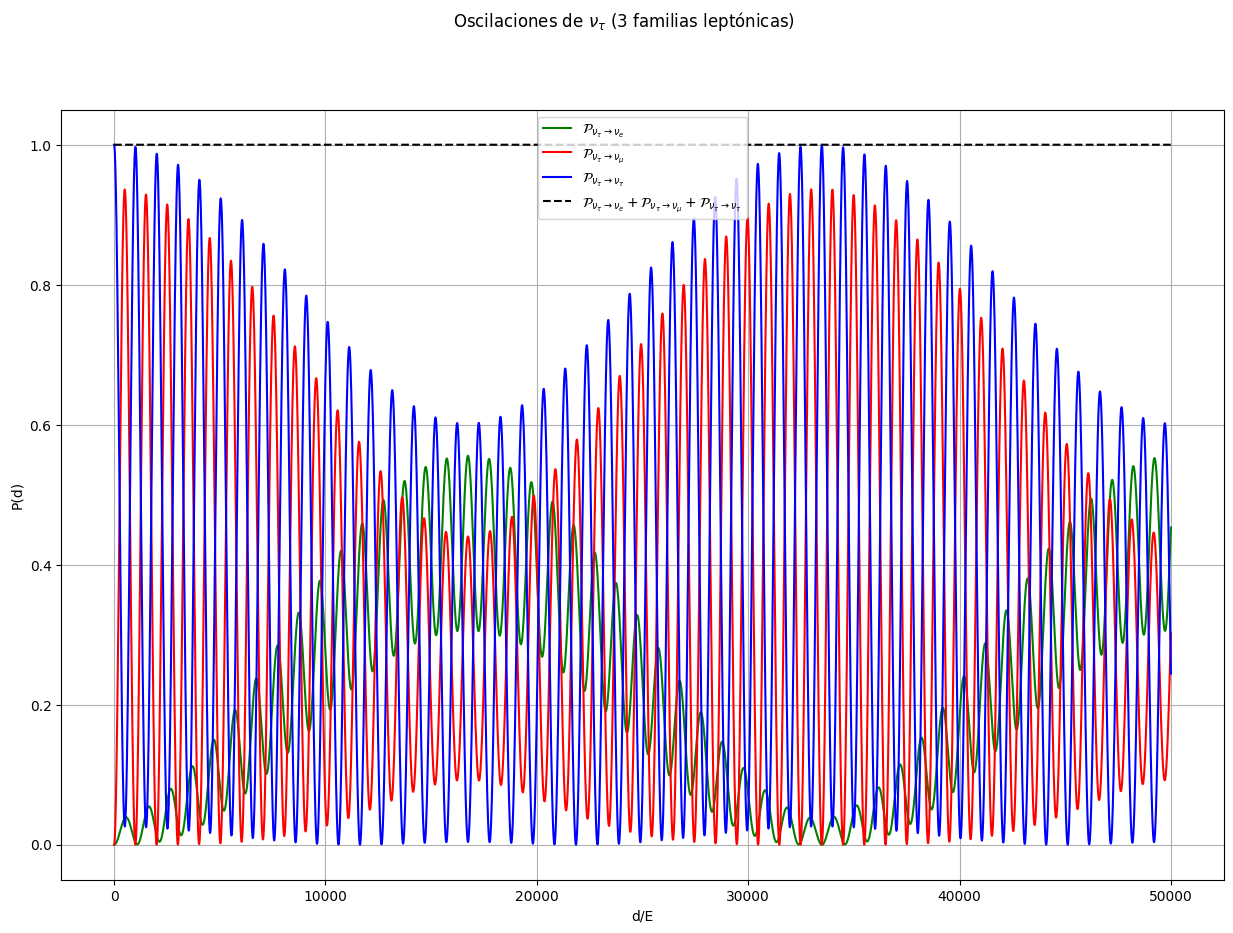

In [82]:
# Completar las probabilidades de oscilación.
# Caso con un neutrino tau inicial.


Probtaue_d = Prob3_taue.subs(valores3)
Probtaumu_d = Prob3_taumu.subs(valores3)
Probtautau_d = Prob3_tautau.subs(valores3)

Probtaue = lambdify(d, Probtaue_d, "numpy")
Probtaumu = lambdify(d, Probtaumu_d, "numpy")
Probtautau = lambdify(d, Probtautau_d, "numpy")


# Creamos un plot:
# Recordad el factor de conversión en las distancias


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probtaue(dist), 'g-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_e}$') 
ax.plot(dist / 5.076, Probtaumu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probtautau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_{\tau}}$')
ax.plot(dist / 5.076, Probtaue(dist) + Probtaumu(dist) + Probtautau(dist), 'k--', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_e} + \mathcal{P}_{\nu_{\tau}\to\nu_{\mu}} + \mathcal{P}_{\nu_{\tau}\to\nu_{\tau}}$') 

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d)")
ax.legend(loc="upper center")

fig.suptitle("Oscilaciones de $\\nu_\\tau$ (3 familias leptónicas)") 



<font size="3">

A continuación estudiaremos las oscilaciones anteriores, en dos casos físicos concretos.

# Neutrinos atmosféricos


<font size="3">
Nos referimos con neutrinos atmosféricos a los neutrinos que se producen por la colisión de rayos cósmicos con partículas de la atmósfera. En estas colisiones, típicamente de protones, se produce una cascada de partículas que incluye desintegraciones a piones, que se desintegran en $\mu +\bar{\nu}_\mu$, y finalmente se desintegra el muón en $e + \bar{\nu}_e + \nu_\mu$. Por tanto, se esperaría que por cada neutrino electrónico hubiese $2$ muónicos. Esta predicción nos da un flujo esperado muy concreto, pero no es esto lo que se observaba, y por ello ha tenido gran importancia el estudio de los neutrinos atmosféricos para establecer las oscilaciones.

En este caso se estudiará la probabilidad de supervivencia de un neutrino electrónico o muónico y de su conversión en otro sabor. Como para la atmósfera estamos hablando de distancias relativamente pequeñas (no más de 800kms), nos interesarán valores en los que $d/E$ es pequeño (digamos $d/E \leq 10^3$). 

Notamos que con valores pequeños de ese cociente, y a la vista de los valores para las masas, los términos que van con $\Delta m^2_{12}$ van a ser despreciables frente al resto (tenemos el seno de algo muy pequeño), por lo que podemos hacer un desarrollo y quedarnos con los términos dominantes. Podemos además tomar una segunda aproximación, y es que un ángulo es más pequeño que los otros, por lo que tendremos $\theta_{13}\sim0$, es decir, $\sin(\theta_{13}\sim 0), \, \cos(\theta_{13}\sim 1)$. Tomando todas estas aproximaciones podemos comprobar que el término dominante (a partir de la ecuación que escribíamos justo arriba) es la transición de $\nu_\mu$ a $\nu_\tau$: 

$$ \mathcal{P}_{\nu_\mu\to\nu_\tau} \simeq \sin^2(2 \theta_{23}) \sin^2\left(\frac{\Delta m^2_{23}}{4} \frac{d}{E} \right) \ . $$

Es decir, que de los neutrinos iniciales, se espera que al recorrer la atmósfera los $\nu_e$ sigan siéndolo, mientras que los $\nu_\mu$ oscilan a $\nu_\tau$.  

Comprobaremos a continuación el cálculo numérico completo para ver la validez de la aproximación utilizada.

<font size="3"> En primer lugar representamos la probabilidad de encontrar cada tipo de neutrino partiendo de un neutrino electrónico para el rango de kms relevante de la atmósfera. Donde vemos que, efectivamente, encontraremos mayoritariamente neutrinos electrónicos.

<font size="3">

_Nota: en estos casos físicos, tanto para neutrinos atmosféricos como para neutrinos solares que se verá en el siguiente apartado, representaremos los resultados en función del cociente $d/E$. En ambos casos, el espectro de energías de los neutrinos iniciales es amplio, por lo que no tiene sentido fijar un único valor concreto para la energía. Lo que realmente nos interesa es que la proporción distancia-energía sea muy grande (neutrinos solares) o muy pequeña (neutrinos atmosféricos). Para evaluar esto en nuestro cálculo, lo más sencillo es tomar $E=1$, pasando la variable $d$ a representar $d/E$, que es la que vamos a representar en las gráficas (véase que esto es mucho más simple que redefinir todas las expresiones con una nueva variable, y proporciona el mismo resultado para las gráficas)._

<font size="3">

En primer lugar, hacemos la gráfica para el caso de neutrino muónico inicial. Representamos también la probabilidad aproximada que razonábamos antes.

In [84]:
# Escribir la expresión analítica aproximada.

Prob_aprox = sin(2*th23)**2 * sin(DeltaM32/4 * d/E)**2

Prob_aprox_mu = lambdify(d, Prob_aprox.subs(E,1).subs(valores).subs(valores3), "numpy")

In [85]:
# Recalculamos los valores, teniendo en cuenta la nota anterior.
# Véase que sustituyendo primero la energía por 1 evitamos que la sustituya por otros valores empleados.
# Completar.

dist = 5.076 * np.linspace(0, 5 * 10 ** 2, 10 ** 2)

Probmue = lambdify(d, Prob3_mue.subs(E,1).subs(valores3), "numpy")
Probmumu = lambdify(d, Prob3_mumu.subs(E,1).subs(valores3), "numpy")
Probmutau = lambdify(d, Prob3_mutau.subs(E,1).subs(valores3), "numpy")

Text(0.5, 0.98, 'Oscilaciones de $\\nu_\\mu$ para distancias cortas (3 familias)')

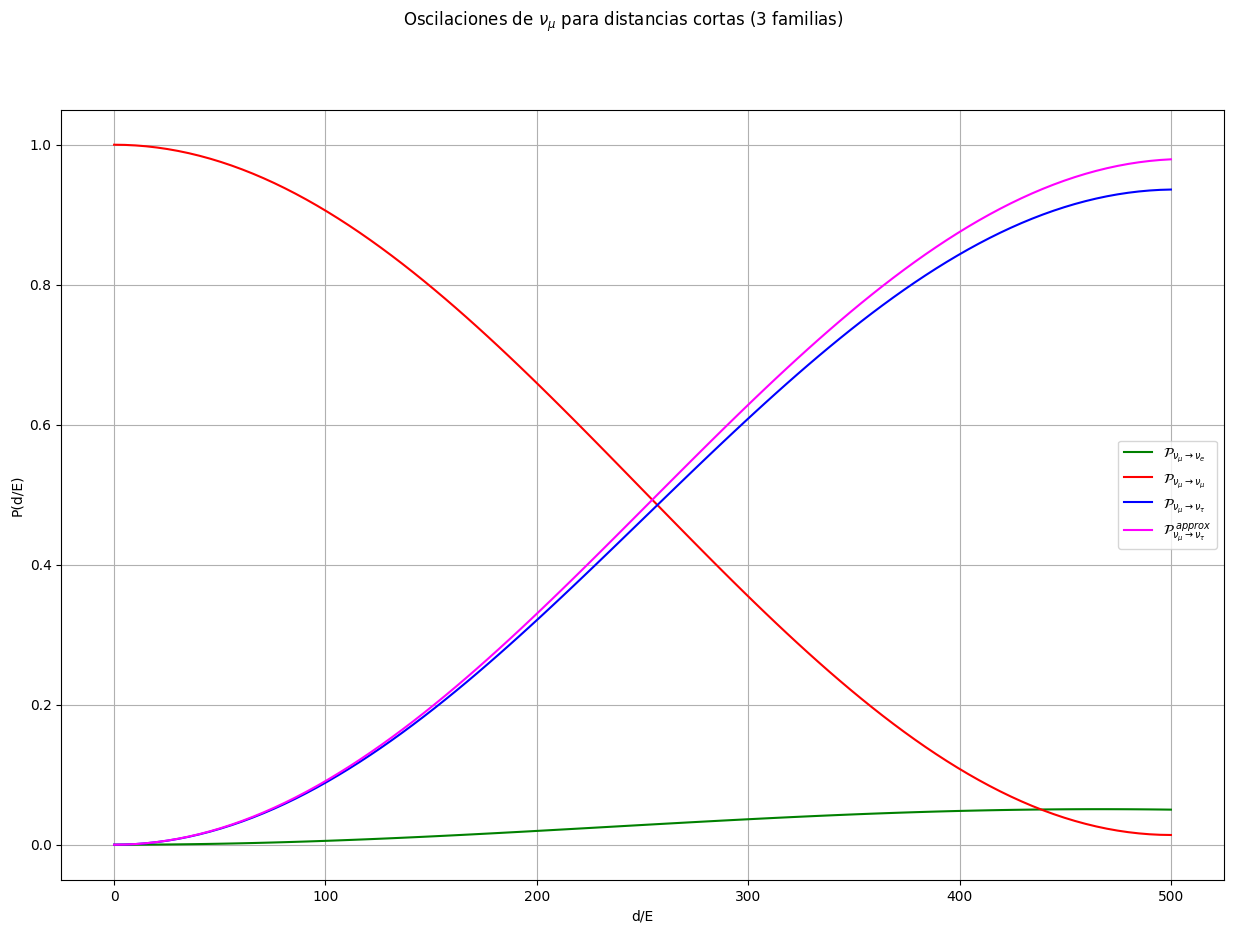

In [91]:
# Creamos un plot:  Probmue, Probmumu y Probmutau frente a dist, y la expresión aproximada
# Recordad el factor de conversión en las distancias, y que representamos d/E.


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probmue(dist), 'g-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_e}$') 
ax.plot(dist / 5.076, Probmumu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probmutau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\tau}}$')

ax.plot(dist / 5.076, Prob_aprox_mu(dist), 'fuchsia', label=r'$\mathcal{P}_{\nu_{\mu}\to\nu_{\tau}}^{\ approx}$')

x_min, x_max, y_min, y_max = ax.axis('tight') 
ax.axis([x_min, x_max, y_min, y_max]) 
ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d/E)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_\\mu$ para distancias cortas (3 familias)") 



<font size="3">

Según lo visto, la única oscilación relevante es la del neutrino mu. ¿Qué pasa entonces con los neutrinos electrónicos? Para ello realizamos el mismo cálculo, comprobando que siguen siendo electrónicos en el rango considerado.

In [92]:
# Completar:

Probee = lambdify(d, Prob3_ee.subs(E,1).subs(valores3), "numpy")
Probemu = lambdify(d, Prob3_emu.subs(E,1).subs(valores3), "numpy")
Probetau = lambdify(d, Prob3_etau.subs(E,1).subs(valores3), "numpy")

Text(0.5, 0.98, 'Oscilaciones de $\\nu_e$ para distancias cortas (3 familias)')

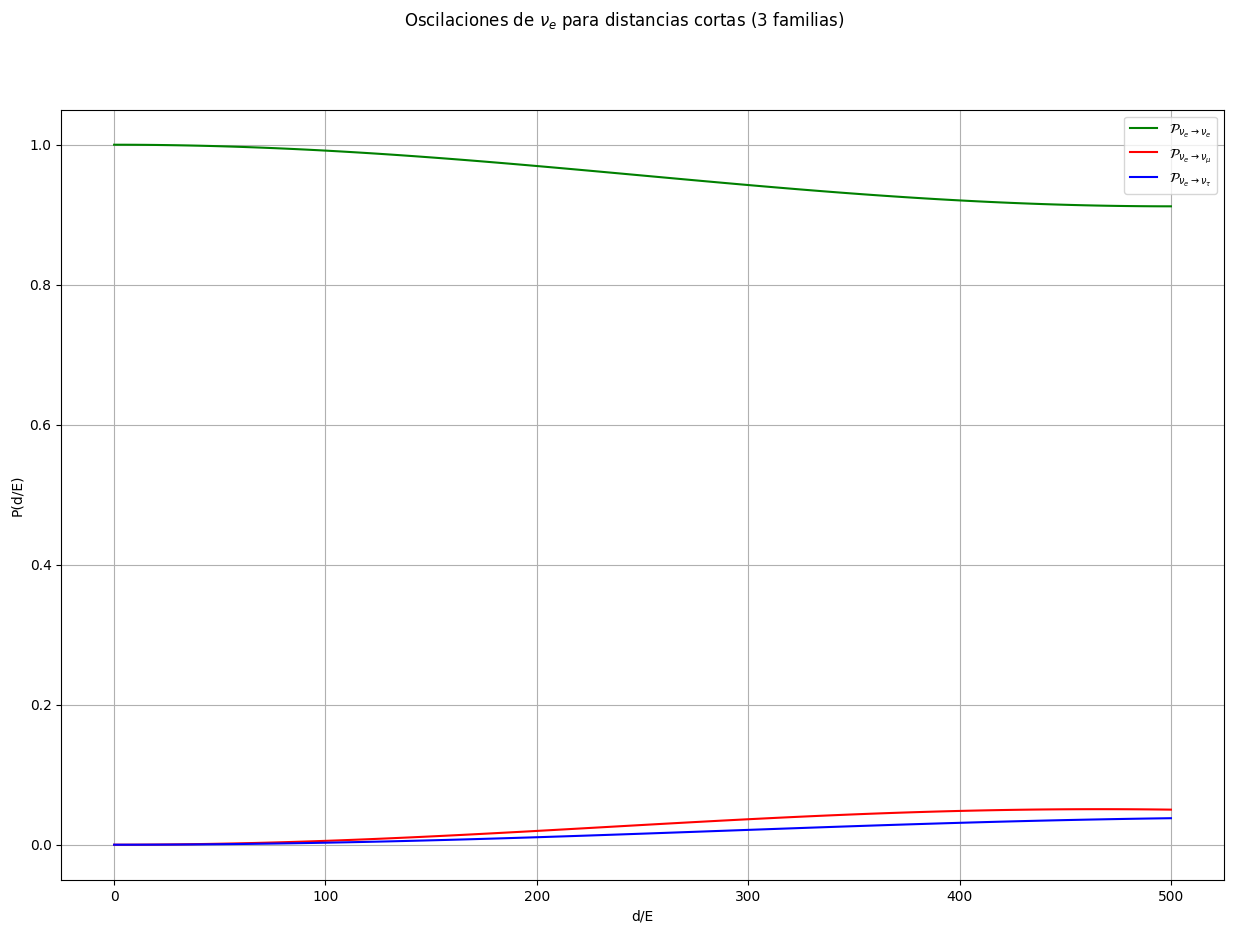

In [95]:
# Creamos un plot: 
# recordad el factor de conversión en las distancias

fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_e}$') 
ax.plot(dist / 5.076, Probemu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probetau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\tau}}$')


ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d/E)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_e$ para distancias cortas (3 familias)") 



**Conclusión:** efectivamente, los neutrinos electrónicos apenas oscilan a distancias cortas, de modo que es buena aproximación considerar que las únicas oscilaciones relevantes son $\nu_\mu \to \nu_\tau$. Yo me pregunto ahora si estas oscilaciones son bidireccionales, esto es: hemos visto que, conforme penetran en la atmósfera, los neutrinos muónicos oscilan y aumenta la probabilidad de medirlos como tauónicos. Si a mitad de camino medimos un neutrino que inicialmente era muónico y lo detectamos como tauónico y luego dejamos que siga propagándose, me pregunto si existe una probabilidad no-despreciable de volver a medirlo como muónico. La comprobación es sencilla, basta con hacer el mismo plot que antes pero para $\nu_\tau$:

In [96]:
Probtaue = lambdify(d, Prob3_taue.subs(E,1).subs(valores3), "numpy")
Probtaumu = lambdify(d, Prob3_taumu.subs(E,1).subs(valores3), "numpy")
Probtautau = lambdify(d, Prob3_tautau.subs(E,1).subs(valores3), "numpy")

Text(0.5, 0.98, 'Oscilaciones de $\\nu_\\tau$ para distancias cortas (3 familias)')

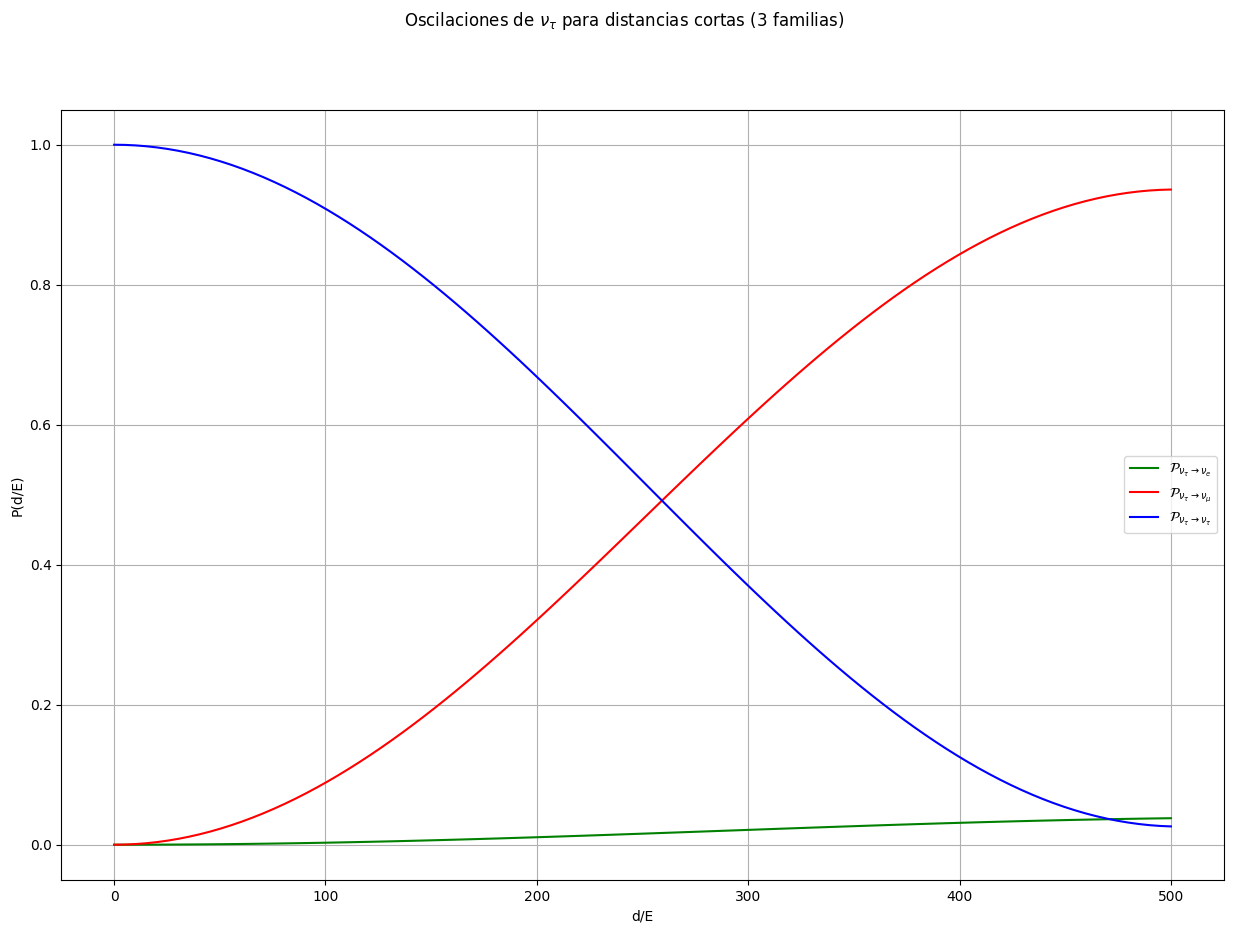

In [97]:
fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probtaue(dist), 'g-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_e}$') 
ax.plot(dist / 5.076, Probtaumu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probtautau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{\tau}\to\nu_{\tau}}$')


ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d/E)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_\\tau$ para distancias cortas (3 familias)") 

**Observación:** efectivamente, no es que a cortas distancias perdamos neutrinos muónicos al canal tauónico, sino que hay oscilaciones

### Neutrinos solares

<font size="3">

En este caso, al contrario que en el anterior, lo que tenemos es una distancia muy larga, con lo que podremos realizar otras aproximaciones. En el Sol los neutrinos que se producen son electrónicos. El flujo de dichos neutrinos también está bien establecido, ya que es una predicción directa del modelo solar; mediante el llamado ciclo p-p, el Sol produce unas cantidades determinadas de neutrinos con unas energías determinadas. En este caso el problema se dio porque cuando se empezaron a medir neutrinos procedentes del Sol (sólo electrónicos), las observaciones no concordaban con las predicciones del flujo solar, sino que se observaban menos neutrinos. Como ahora sabemos, esto se debía a que los neutrinos estaban oscilando en su propagación, y por tanto no todos podían ser detectados mediante técnicas que en un principio sólo buscaban los electrónicos. Con nuevos detectores que eran capaces de detectarlos todos e incluso discriminar entre sabores (como por ejemplo SNO), se comprobó que el flujo solar estaba bien calculado, y que si incluíamos todos los sabores se detectaba la cantidad adecuada de neutrinos. 

Estudiaremos así en este caso la probabilidad de supervivencia o transición de un neutrino inicialmente electrónico para largas distancias. Asumiendo que $L\gg E$, tendremos que los términos sinusoidales van a oscilar rápidamente, si el valor de $\Delta m^2$ es también grande. Esto nos lleva a que podamos promediar los términos que incluyan $\Delta m^2_{31}$ y $\Delta m^2_{32}$ (no los de $\Delta m^2_{21}$ que es más pequeño). Realizando estas aproximaciones se puede llegar a la siguiente expresión:

$$ \mathcal{P}_{\nu_\beta\to\nu_\alpha} \simeq -4 U_{\alpha1}U_{\beta1}U_{\alpha2}U_{\beta2} \sin^2\left(\frac{\Delta m^2_{12} (eV^2)}{4} \frac{d}{E}\right) - 2 (U_{\alpha1}U_{\beta1}U_{\alpha3}U_{\beta3} + U_{\alpha2}U_{\beta2}U_{\alpha3}U_{\beta3})\ , $$

y simplificando más,

$$ \mathcal{P}_{\nu_e\to\nu_{\mu,\tau}} \simeq \sin^2(2 \theta_{23}) \sin^2\left(\frac{\Delta m^2_{12} (eV^2)}{4} \frac{d}{E}\right) \ . $$

De nuevo haremos el estudio numérico completo y comprobaremos la validez de esta aproximación.


In [98]:
# Valores de distancia a evaluar: [d] = km
# creamos un array de datos

dist = 5.076 * np.linspace(0, 1 * 10 ** 5, 10 ** 4 )

In [99]:
# Completar.
# Recordad la nota sobre el valor de la energía.

Probee = lambdify(d, Prob3_ee.subs(E,1).subs(valores3), "numpy")
Probemu = lambdify(d, Prob3_emu.subs(E,1).subs(valores3), "numpy")
Probetau = lambdify(d, Prob3_etau.subs(E,1).subs(valores3), "numpy")

Text(0.5, 0.98, 'Oscilaciones de $\\nu_e$ para largas distancias (3 familias)')

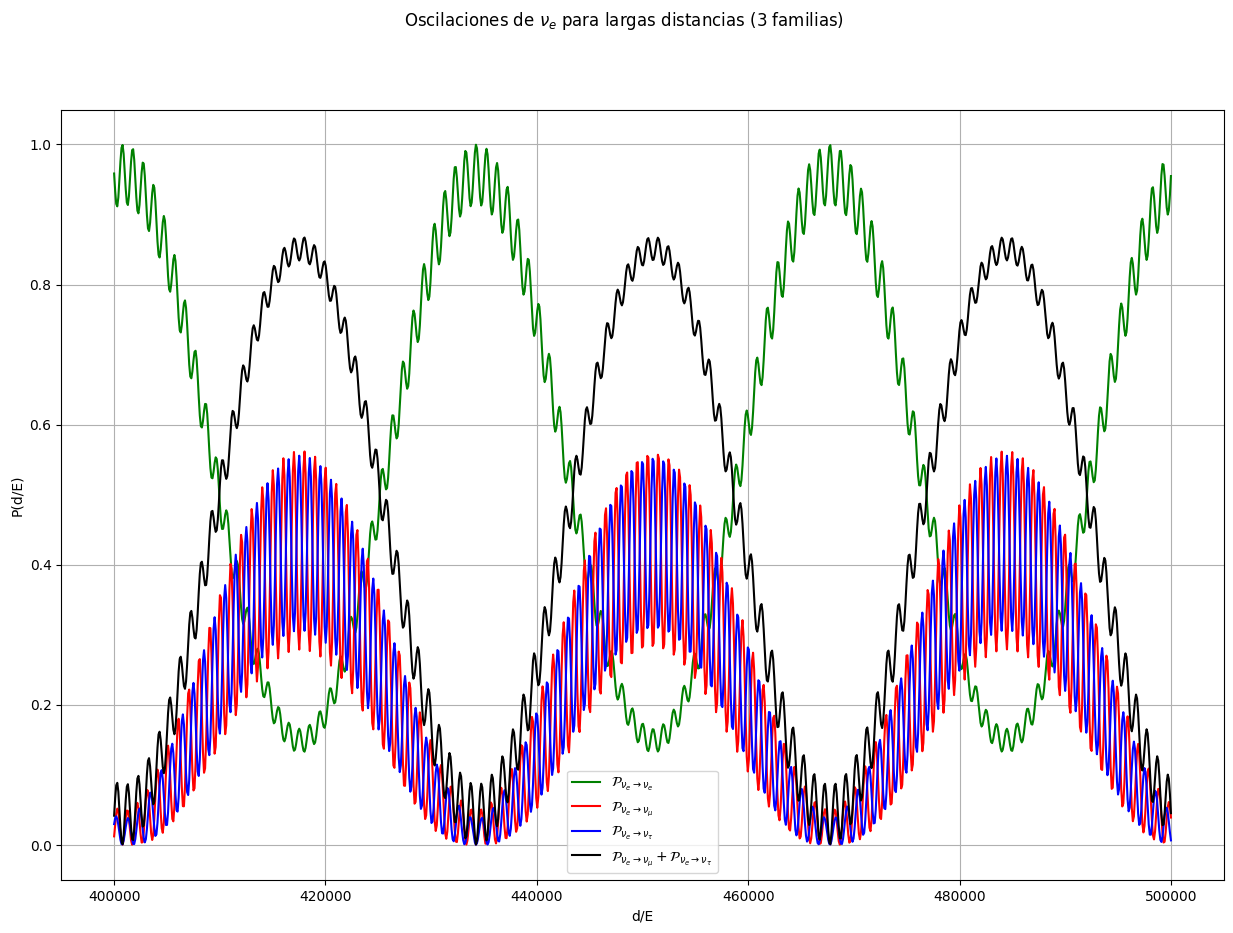

In [111]:
# Creamos un plot:  Probee, Probemu y Probetau frente a dist, y la suma de Probemu + Probetau
# Recordad el factor de conversión en las distancias, y que representamos d/E.


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_e}$') 
ax.plot(dist / 5.076, Probemu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probetau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\tau}}$')
ax.plot(dist / 5.076, Probemu(dist)+Probetau(dist), 'k-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\mu}}+\mathcal{P}_{\nu_{e}\to\nu_{\tau}}$')

ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d/E)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_e$ para largas distancias (3 familias)") 




<font size="3">

Comprobamos la aproximación, válida a largas distancias.

In [101]:
# Valores de distancia a evaluar: [d] = km
# Completar.

dist = 5.076 * np.linspace(4 * 10 ** 5, 5 * 10 ** 5, 10 ** 3)

Probee = lambdify(d, Prob3_ee.subs(E,1).subs(valores3), "numpy")
Probemu = lambdify(d, Prob3_emu.subs(E,1).subs(valores3), "numpy")
Probetau = lambdify(d, Prob3_etau.subs(E,1).subs(valores3), "numpy")

# Teníamos una expresión aproximada sencilla:
# Prob_aprox2 = 1 * (sin(2 * th23) ** 2) * ( sin(DeltaM21 * d / (4 * E)) ) ** 2
# Sin embargo, tenemos otra expresión aproximada que incluye más elementos de matriz,
# utilizaremos esta ya que ajusta mejor:

val1 = -4 * ( M_3[1, 0] * M_3[0, 0] * M_3[1, 1] * M_3[0, 1] + 
      M_3[2, 0] * M_3[0, 0] * M_3[2, 1] * M_3[0, 1] )
val2 = -2 * ( M_3[1, 0] * M_3[0, 0] * M_3[1, 2] * M_3[0, 2] + 
      M_3[1, 1] * M_3[0, 1] * M_3[1, 2] * M_3[0, 2] + 
      M_3[2, 0] * M_3[0, 0] * M_3[2, 2] * M_3[0, 2] + 
      M_3[2, 1] * M_3[0, 1] * M_3[1, 2] * M_3[0, 2] )

Prob_aprox2 =  val1 * ( sin(DeltaM21 * d / (4 * E)) ) ** 2 + val2

Prob_aprox_e = lambdify(d, Prob_aprox2.subs(E,1).subs(valores).subs(valores3), "numpy")

Text(0.5, 0.98, 'Oscilaciones de $\\nu_e$ para largas distancias (3 familias)')

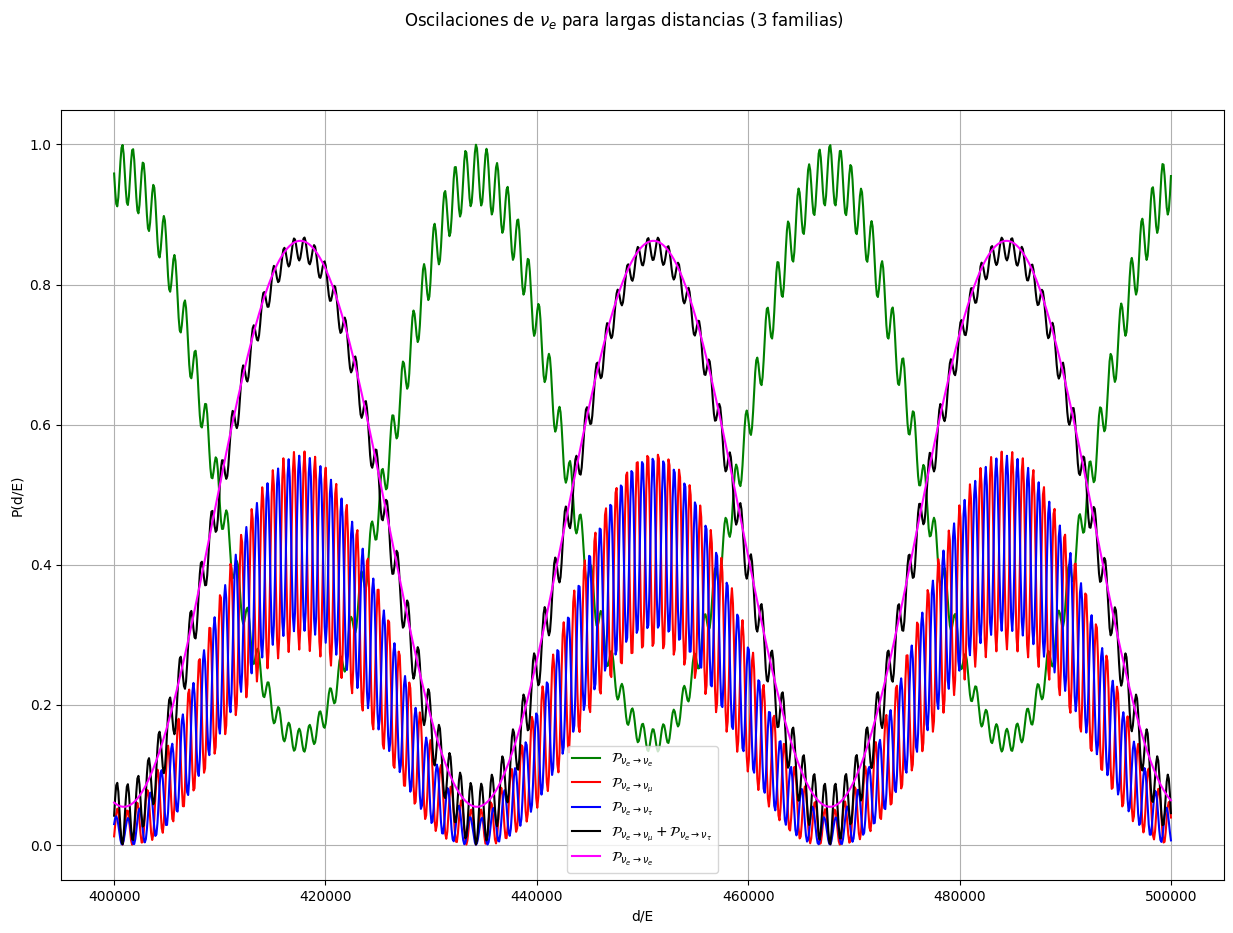

In [110]:
# Creamos un plot: Probee, Probemu y Probetau frente a dist, la expresión aproximada y la suma 
# Recordad el factor de conversión en las distancias.


fig, ax = plt.subplots(1, figsize=(15,10)) 
ax.grid(True) 

ax.plot(dist / 5.076, Probee(dist), 'g-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_e}$') 
ax.plot(dist / 5.076, Probemu(dist), 'r-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\mu}}$') 
ax.plot(dist / 5.076, Probetau(dist), 'b-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\tau}}$')
ax.plot(dist / 5.076, Probemu(dist)+Probetau(dist), 'k-', label=r'$\mathcal{P}_{\nu_{e}\to\nu_{\mu}}+\mathcal{P}_{\nu_{e}\to\nu_{\tau}}$')

ax.plot(dist / 5.076, Prob_aprox_e(dist), 'fuchsia', label=r'$\mathcal{P}_{\nu_{e}\to\nu_e}$')

ax.grid(True)
ax.set_xlabel("d/E")
ax.set_ylabel("P(d/E)")
ax.legend()

fig.suptitle("Oscilaciones de $\\nu_e$ para largas distancias (3 familias)")  



**Observación:** a lo largo de esta segunda parte de la práctica, he notado que el fenómeno de oscilaciones de neutrinos es muy similar al de los batidos y pulsaciones en acústica. Si hay solo dos neutrinos, la probabilidad de supervivencia del neutrino inicial viene dado por una función sinusoidal sencilla, pero si se incluyen más sabores, pasa a haber un fenómeno de batido, en el sentido de que hay unas oscilaciones "a pequeña escala" y otras "a gran escala" (la envolvente), confiriendo a la probabilidad el carácter de batido. Observo que la aproximación considerada para los neutrinos solares es buena para determinar la envolvente, pero que de ninguna forma resuelve las oscilaciones "a pequeña escala"

In [109]:
print("--- %.2f seconds ---" % (time.time() - start_time))
print("--- %.2f minutes ---" % ((time.time() - start_time) / 60))

--- 6720.56 seconds ---
--- 112.01 minutes ---


# Preguntas abiertas

Esta práctica da lugar a tres preguntas obligadas: dos de naturaleza Física y la otra, epistemológica

1. ¿Cuál es el fenómeno que subyace a las oscilaciones de los neutrinos? ¿Se trata  de una interacción fundamental nueva, tal vez a una escala tan pequeña que no la hemos resuelto aún? O bien: yo sé que la interacción débil es la única que es capaz de cambiar el sabor de las cosas, y sé que es la única interacción (aparte de gravedad) a la que se acoplan los neutrinos: ¿podríamos explicar las oscilaciones de neutrinos a través de la interacción débil? Esta última pregunta es digna de consideración porque, aunque en esta práctica hemos tratado los neutrinos como partículas libres, es una predicción (aún no comprobada) del Modelo Estándar de la Cosmología que el Universo se encuentra permeado por un fondo cósmico de neutrinos, de modo que un neutrino generado en el Sol podría interactuar con los de dicho fondo, dando lugar a un neutrino de distinto sabor. Esto va en contra de cómo hemos modelado las oscilaciones de neutrinos, porque esta descripción postula implícitamente que estos (como estados asintóticos) siempre tienen sabor bien definido, y no oscilan en masa, sino que estos cambios de sabor podrían deberse a la compleja interacción de los neutrinos con otras partículas del medio, con el fondo cósmico de neutrinos (si existe) o, incluso, con el propio vacío.

2. En el sistema de referencia de la Tierra, los neutrinos son típicamente ultrarrelativistas. Sin embargo, a lo largo de esta práctica, nosotros hemos empleado la ecuación de Schrödinger para resolver su dinámica. Esto plantea la pregunta de si realmente estamos aplicando el marco teórico adecuado para estudiar las oscilaciones de neutrinos en primer lugar. Supongo que sí porque el tratamiento que hemos hecho es puramente fenomenológico, en tanto que pretendemos únicamente dar una descripción del fenómeno de las oscilaciones de masa matcheando a experimentación cuando sea necesario. Incluso si en el futuro se descubre que las oscilaciones de neutrinos son un fenómeno con raíces relativistas (e.g: involucra aniquilación / creación), entiendo que este procedimiento seguiría siendo válido como descripción fenomenológica. Sin embargo, sí que haría al caso dar una estimación de la escala de energías a la que esta descripción es válida

3. ¿Si somos capaces de realizar una descripción tan precisa de un fenómeno desconociendo completamente su explicación, realmente esta es necesaria? Considero que adoptar esta visión sería un enaltecimiento exacerbado de la fenomenología, pero esta no es un fin sino el primer medio para comenzar a entender fenómenos aún desconocidos. Tal vez una pregunta más procedente sería si podemos recuperar el comportamiento oscilatorio modelándolo a partir de algún proceso que ya esté incluido en el Modelo Estándar, y esto nos lleva de vuelta a la Pregunta 1

## Referencias


[PDG: _Neutrino masses, mixing and oscillations_](http://pdg.lbl.gov/2019/reviews/rpp2019-rev-neutrino-mixing.pdf)

[$\nu$fit: _data from global three-neutrino fit_](http://www.nu-fit.org/?q=node/211)

Halzen, Martin: _Quarks and leptons_

Cheng, Li: _Gauge theory of elementary particle physics_

D. J. Griffiths: _Introduction to elementary particles._


______________________________________________________________________________________________________